# 08 — Dashboard Data and Final Results

## Objective

This notebook closes the **Fintech Liquidity Forecasting and Reserve Optimization** project by consolidating the validated outputs from the previous notebooks into a small set of final datasets, figures, business conclusions, and README-ready results.

All modeling decisions are treated as frozen. This notebook does **not** perform model development, hyperparameter tuning, probabilistic-method selection, or reserve-policy optimization.

The final validated pipeline entering this notebook is:

* **Point forecast model:** `calendar_promotion_trend_arima011_errors`
* **Daily probabilistic method:** `empirical_log_expanding`
* **Five-day joint uncertainty method:** `moving_block_log_bootstrap`
* **Operational funding horizon:** 5 days
* **Selected reserve policy:** `reserve_p99`
* **Cost scenario:** 19:1 shortfall-to-idle-capital
* **Sensitivity policy:** `reserve_p90`

The main goals of this notebook are to:

1. Validate the Notebook 07 handoff and recover frozen final artifacts.
2. Build compact dashboard-ready datasets from validated outputs.
3. Consolidate final point-forecast, probabilistic, and liquidity-policy KPIs.
4. Select a small set of non-redundant figures for the portfolio and README.
5. Document the final treasury recommendation, assumptions, and limitations.
6. Verify repository completeness and reproducibility.
7. Produce the final project audit and README-ready result tables.

The P99 reserve must be interpreted as the selected policy **under the illustrative 19:1 cost scenario**, not as a universal optimum or a guaranteed 99% service level.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

# ---------------------------------------------------------------------
# Project paths
# ---------------------------------------------------------------------
PROJECT_ROOT = Path(
    r"C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting"
)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
DASHBOARD_DIR = PROJECT_ROOT / "dashboard"

assert PROJECT_ROOT.exists(), f"Project root not found: {PROJECT_ROOT}"
assert PROCESSED_DIR.exists(), f"Processed-data directory not found: {PROCESSED_DIR}"
assert FIGURES_DIR.exists(), f"Figures directory not found: {FIGURES_DIR}"

# Dashboard outputs will be created only when needed.
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# Mandatory Notebook 07 handoff artifacts
# ---------------------------------------------------------------------
handoff_files = {
    "notebook08_handoff": PROCESSED_DIR / "07_notebook08_handoff.csv",
    "technical_summary": PROCESSED_DIR / "07_notebook07_technical_summary.csv",
    "closure_audit": PROCESSED_DIR / "07_notebook07_closure_audit.csv",
    "artifact_registry": PROCESSED_DIR / "07_notebook07_artifact_registry.csv",
}

missing_files = [
    str(path)
    for path in handoff_files.values()
    if not path.exists()
]

assert not missing_files, (
    "Missing mandatory Notebook 07 handoff files:\n"
    + "\n".join(missing_files)
)

# Load the frozen handoff artifacts.
notebook08_handoff = pd.read_csv(handoff_files["notebook08_handoff"])
notebook07_technical_summary = pd.read_csv(handoff_files["technical_summary"])
notebook07_closure_audit = pd.read_csv(handoff_files["closure_audit"])
notebook07_artifact_registry = pd.read_csv(handoff_files["artifact_registry"])

# ---------------------------------------------------------------------
# Minimal startup inspection
# ---------------------------------------------------------------------
startup_overview = pd.DataFrame(
    {
        "artifact": [
            "07_notebook08_handoff.csv",
            "07_notebook07_technical_summary.csv",
            "07_notebook07_closure_audit.csv",
            "07_notebook07_artifact_registry.csv",
        ],
        "rows": [
            len(notebook08_handoff),
            len(notebook07_technical_summary),
            len(notebook07_closure_audit),
            len(notebook07_artifact_registry),
        ],
        "columns": [
            notebook08_handoff.shape[1],
            notebook07_technical_summary.shape[1],
            notebook07_closure_audit.shape[1],
            notebook07_artifact_registry.shape[1],
        ],
    }
)

print("Notebook 08 startup files loaded successfully.")
display(startup_overview)

print("\nNotebook 07 handoff:")
display(notebook08_handoff)

print("\nNotebook 07 technical summary:")
display(notebook07_technical_summary)

print("\nNotebook 07 closure audit:")
display(notebook07_closure_audit)

Notebook 08 startup files loaded successfully.


,artifact,rows,columns
0,07_notebook08_handoff.csv,29,3
1,07_notebook07_technical_summary.csv,1,40
2,07_notebook07_closure_audit.csv,12,4
3,07_notebook07_artifact_registry.csv,87,8



Notebook 07 handoff:


,section,key,value
0,status,notebook07_status,VALIDATED_NOTEBOOK07_PROBABILISTIC_FORECASTING...
1,point_forecast,final_point_model,calendar_promotion_trend_arima011_errors
2,probabilistic_forecast,daily_probabilistic_method,empirical_log_expanding
3,probabilistic_forecast,joint_five_day_method,moving_block_log_bootstrap
4,probabilistic_forecast,funding_lead_time_days,5
5,reserve_policy,selected_policy,reserve_p99
6,reserve_policy,selected_quantile,0.99
7,reserve_policy,sensitivity_policy,reserve_p90
8,reserve_policy,operational_cost_ratio,19.0
9,reserve_policy,p95_p99_break_even_ratio,17.0653



Notebook 07 technical summary:


,notebook,notebook_status,final_point_model,point_model_status,daily_probabilistic_method,daily_probabilistic_evaluation_rows,daily_probabilistic_evaluation_folds,daily_p95_coverage,daily_p99_coverage,daily_pi90_coverage,...,analyst_adjustments_applied,settlement_status,evidence_limitation,next_notebook,next_step_status,registered_artifacts,registered_processed_tables,registered_figures,closure_checks_passed,closure_checks_failed
0,07_probabilistic_forecasting_and_liquidity_policy,VALIDATED_NOTEBOOK07_PROBABILISTIC_FORECASTING...,calendar_promotion_trend_arima011_errors,FROZEN_FROM_NOTEBOOK06,empirical_log_expanding,420,15,0.969048,0.992857,0.930952,...,0,CONDITIONAL_SCENARIO_ONLY,Five-day policy evidence is based on 15 preque...,08_dashboard_data_and_final_results,READY_FOR_NOTEBOOK08_DASHBOARD_AND_FINAL_RESULTS,87,82,5,12,0



Notebook 07 closure audit:


,check,observed,expected,status
0,all_previous_audits_pass,True,True,PASS
1,final_point_model_remains_frozen,calendar_promotion_trend_arima011_errors,calendar_promotion_trend_arima011_errors,PASS
2,daily_probabilistic_method_selected,empirical_log_expanding,empirical_log_expanding,PASS
3,joint_five_day_method_selected,moving_block_log_bootstrap,moving_block_log_bootstrap,PASS
4,one_final_reserve_policy_selected,reserve_p99,reserve_p99,PASS
5,sensitivity_policy_retained,reserve_p90,reserve_p90,PASS
6,daily_probabilistic_rows,420,420,PASS
7,five_day_evaluation_windows,15,15,PASS
8,operational_shortfall_windows,1,1,PASS
9,analyst_adjustments_not_applied,0,0,PASS


## 1. Recover Frozen Operational Results

Notebook 08 starts from the validated outputs of Notebook 07. All modeling and policy decisions are treated as frozen.

This section recovers the final operational artifacts required to build the dashboard and README-ready results:

* five-day liquidity recommendations;
* operational KPI summary;
* final liquidity-policy decision;
* selected five-day cumulative forecasts.

No forecasts, simulations, quantiles, or reserve policies are recomputed here. The purpose is only to verify and consolidate previously validated results.


In [2]:
# ---------------------------------------------------------------------
# Recover the principal frozen operational artifacts from Notebook 07
# ---------------------------------------------------------------------
required_operational_files = {
    "operational_recommendations":
        "07_operational_liquidity_recommendations.csv",

    "operational_summary":
        "07_operational_liquidity_recommendation_summary.csv",

    "final_policy_decision":
        "07_final_liquidity_policy_decision.csv",

    "five_day_forecasts":
        "07_selected_five_day_cumulative_forecasts.csv",
}

# Check that every required filename appears somewhere in the
# Notebook 07 artifact registry.
registry_as_text = notebook07_artifact_registry.astype(str)

registry_validation = []

for artifact_name, filename in required_operational_files.items():
    registered = registry_as_text.apply(
        lambda col: col.str.contains(filename, regex=False, na=False)
    ).any().any()

    file_path = PROCESSED_DIR / filename

    registry_validation.append(
        {
            "artifact": artifact_name,
            "filename": filename,
            "registered_in_notebook07": registered,
            "file_exists": file_path.exists(),
        }
    )

registry_validation = pd.DataFrame(registry_validation)

display(registry_validation)

assert registry_validation["registered_in_notebook07"].all(), (
    "At least one required operational artifact is missing "
    "from the Notebook 07 artifact registry."
)

assert registry_validation["file_exists"].all(), (
    "At least one required operational artifact is missing "
    "from data/processed/."
)

# ---------------------------------------------------------------------
# Load the frozen tables
# ---------------------------------------------------------------------
operational_recommendations = pd.read_csv(
    PROCESSED_DIR / required_operational_files["operational_recommendations"]
)

operational_summary = pd.read_csv(
    PROCESSED_DIR / required_operational_files["operational_summary"]
)

final_policy_decision = pd.read_csv(
    PROCESSED_DIR / required_operational_files["final_policy_decision"]
)

five_day_forecasts = pd.read_csv(
    PROCESSED_DIR / required_operational_files["five_day_forecasts"]
)

# ---------------------------------------------------------------------
# Inspect dimensions and schemas before consolidation
# ---------------------------------------------------------------------
operational_artifact_overview = pd.DataFrame(
    {
        "dataset": [
            "operational_recommendations",
            "operational_summary",
            "final_policy_decision",
            "five_day_forecasts",
        ],
        "rows": [
            len(operational_recommendations),
            len(operational_summary),
            len(final_policy_decision),
            len(five_day_forecasts),
        ],
        "columns": [
            operational_recommendations.shape[1],
            operational_summary.shape[1],
            final_policy_decision.shape[1],
            five_day_forecasts.shape[1],
        ],
    }
)

print("Frozen operational artifacts loaded successfully.")
display(operational_artifact_overview)

print("\nOperational recommendation summary:")
display(operational_summary)

print("\nFinal liquidity-policy decision:")
display(final_policy_decision)

print("\nFive-day operational recommendations:")
display(operational_recommendations.head())

,artifact,filename,registered_in_notebook07,file_exists
0,operational_recommendations,07_operational_liquidity_recommendations.csv,True,True
1,operational_summary,07_operational_liquidity_recommendation_summar...,True,True
2,final_policy_decision,07_final_liquidity_policy_decision.csv,True,True
3,five_day_forecasts,07_selected_five_day_cumulative_forecasts.csv,True,True


Frozen operational artifacts loaded successfully.


,dataset,rows,columns
0,operational_recommendations,15,34
1,operational_summary,1,16
2,final_policy_decision,1,36
3,five_day_forecasts,15,20



Operational recommendation summary:


,evaluation_windows,funding_lead_time_days,selected_policy_id,selected_policy_quantile,sensitivity_policy_id,operational_cost_ratio,mean_observed_outflow,mean_point_forecast,mean_selected_reserve,mean_increment_vs_point,shortfall_windows,service_level,total_shortfall_amount,mean_idle_capital,total_operational_cost,analyst_adjustments_applied
0,15,5,reserve_p99,0.99,reserve_p90,19.0,4422.4716,4425.151321,4964.692177,539.540856,1,0.933333,67.38724,546.713059,9481.053446,0



Final liquidity-policy decision:


,decision_scope,selected_policy_id,selected_policy_quantile,decision_status,decision_is_cost_conditional,operational_cost_ratio_shortfall_to_idle,cost_implied_theoretical_quantile,theoretical_policy_id,theoretical_policy_status,daily_probabilistic_method,...,p99_preferred_to_p95_loo_samples,p95_preferred_to_p99_loo_samples,sensitivity_policy_id,sensitivity_policy_minimum_cost_ratio,sensitivity_policy_maximum_cost_ratio,selected_policy_minimum_cost_ratio,selected_policy_maximum_cost_ratio,analyst_adjustment_status,evidence_limitation,selection_reason
0,five_day_liquidity_reserve_policy,reserve_p99,0.99,SELECTED_OPERATIONAL_POLICY_UNDER_19_TO_1,True,19.0,0.95,reserve_p95,REFERENCE_NOT_EMPIRICAL_WINNER,empirical_log_expanding,...,14,1,reserve_p90,4.3,17.3,17.4,100.0,NOT_APPLIED_IN_BACKTEST,The decision uses 15 five-day evaluation windo...,P99 minimizes observed cost under the explicit...



Five-day operational recommendations:


,fold_id,fold_sequence,forecast_origin,target_start,target_end,actual_5d_total,point_5d_total,reserve_p50,reserve_p80,reserve_p90,...,final_reserve,observed_outflow,shortfall_amount,idle_capital_amount,shortfall_event,service_success,operational_cost_ratio_shortfall_to_idle,shortfall_cost,idle_capital_cost,total_operational_cost
0,fold_06,6,2025-06-06,2025-06-07,2025-06-11,4033.844,3539.893106,3492.972358,3643.994355,3799.027906,...,3966.456760,4033.844,67.38724,0.000000,True,False,19.0,1280.357554,0.000000,1280.357554
1,fold_07,7,2025-07-04,2025-07-05,2025-07-09,3462.541,3495.557104,3455.901152,3615.604309,3755.675135,...,3926.834042,3462.541,0.00000,464.293042,False,True,19.0,0.000000,464.293042,464.293042
2,fold_08,8,2025-08-01,2025-08-02,2025-08-06,4064.120,4182.230057,4141.010736,4319.256497,4485.333971,...,4695.277296,4064.120,0.00000,631.157296,False,True,19.0,0.000000,631.157296,631.157296
3,fold_09,9,2025-08-29,2025-08-30,2025-09-03,4637.375,4567.323175,4493.110952,4692.309370,4848.719174,...,5108.802322,4637.375,0.00000,471.427322,False,True,19.0,0.000000,471.427322,471.427322
4,fold_10,10,2025-09-26,2025-09-27,2025-10-01,4442.830,4251.649998,4180.065572,4360.506678,4507.899753,...,4752.752159,4442.830,0.00000,309.922159,False,True,19.0,0.000000,309.922159,309.922159


## 2. Build the Five-Day Liquidity Dashboard Dataset

The validated Notebook 07 operational table contains all information required to evaluate the five-day liquidity decision, but it also includes intermediate fields that are not necessary for final communication.

This section creates a compact dashboard-ready table containing only the variables required to explain:

* the observed five-day cash outflow;
* the frozen point forecast;
* the principal reserve alternatives;
* the selected operational reserve;
* shortfall and idle-capital outcomes;
* service success;
* the cost generated under the 19:1 operating scenario.

No reserve values or costs are recomputed. The table is a direct consolidation of validated Notebook 07 outputs.


In [3]:
# ---------------------------------------------------------------------
# Build the compact five-day operational dashboard dataset
# ---------------------------------------------------------------------

required_columns = [
    "fold_id",
    "fold_sequence",
    "forecast_origin",
    "target_start",
    "target_end",
    "actual_5d_total",
    "point_5d_total",
    "reserve_p90",
    "reserve_p95",
    "reserve_p99",
    "final_reserve",
    "shortfall_amount",
    "idle_capital_amount",
    "shortfall_event",
    "service_success",
    "operational_cost_ratio_shortfall_to_idle",
    "total_operational_cost",
]

missing_columns = [
    col for col in required_columns
    if col not in operational_recommendations.columns
]

assert not missing_columns, (
    "Missing required columns in operational_recommendations: "
    f"{missing_columns}"
)

five_day_dashboard = (
    operational_recommendations[required_columns]
    .copy()
    .sort_values("fold_sequence")
    .reset_index(drop=True)
)

# ---------------------------------------------------------------------
# Standardize date fields
# ---------------------------------------------------------------------
date_columns = [
    "forecast_origin",
    "target_start",
    "target_end",
]

for col in date_columns:
    five_day_dashboard[col] = pd.to_datetime(
        five_day_dashboard[col],
        errors="raise",
    )

# ---------------------------------------------------------------------
# Add only communication-oriented derived fields
# ---------------------------------------------------------------------
five_day_dashboard["reserve_increment_vs_point"] = (
    five_day_dashboard["final_reserve"]
    - five_day_dashboard["point_5d_total"]
)

five_day_dashboard["reserve_margin_vs_actual"] = (
    five_day_dashboard["final_reserve"]
    - five_day_dashboard["actual_5d_total"]
)

# ---------------------------------------------------------------------
# Minimum quality checks
# ---------------------------------------------------------------------
assert len(five_day_dashboard) == 15
assert five_day_dashboard["fold_sequence"].nunique() == 15
assert five_day_dashboard["fold_id"].nunique() == 15

assert five_day_dashboard[
    [
        "actual_5d_total",
        "point_5d_total",
        "reserve_p90",
        "reserve_p95",
        "reserve_p99",
        "final_reserve",
    ]
].notna().all().all()

assert (
    five_day_dashboard["operational_cost_ratio_shortfall_to_idle"]
    == 19.0
).all()

assert five_day_dashboard["shortfall_event"].sum() == 1
assert five_day_dashboard["service_success"].sum() == 14

# The frozen final reserve must correspond to the selected P99 policy.
assert np.allclose(
    five_day_dashboard["final_reserve"],
    five_day_dashboard["reserve_p99"],
)

# ---------------------------------------------------------------------
# Save immediately as a Notebook 08 validated table
# ---------------------------------------------------------------------
five_day_dashboard_path = (
    PROCESSED_DIR / "08_dashboard_five_day_liquidity.csv"
)

five_day_dashboard.to_csv(
    five_day_dashboard_path,
    index=False,
)

assert five_day_dashboard_path.exists()

# ---------------------------------------------------------------------
# Compact validation summary
# ---------------------------------------------------------------------
dashboard_validation = pd.DataFrame(
    {
        "check": [
            "rows",
            "five_day_windows",
            "shortfall_windows",
            "successful_windows",
            "cost_ratio",
            "final_reserve_matches_p99",
            "missing_values",
            "output_file_exists",
        ],
        "observed": [
            len(five_day_dashboard),
            five_day_dashboard["fold_sequence"].nunique(),
            int(five_day_dashboard["shortfall_event"].sum()),
            int(five_day_dashboard["service_success"].sum()),
            five_day_dashboard[
                "operational_cost_ratio_shortfall_to_idle"
            ].unique().tolist(),
            np.allclose(
                five_day_dashboard["final_reserve"],
                five_day_dashboard["reserve_p99"],
            ),
            int(five_day_dashboard.isna().sum().sum()),
            five_day_dashboard_path.exists(),
        ],
        "expected": [
            15,
            15,
            1,
            14,
            [19.0],
            True,
            0,
            True,
        ],
    }
)

dashboard_validation["status"] = np.where(
    dashboard_validation["observed"].astype(str)
    == dashboard_validation["expected"].astype(str),
    "PASS",
    "FAIL",
)

print(f"Saved: {five_day_dashboard_path}")
display(dashboard_validation)

print("\nFive-day dashboard dataset:")
display(five_day_dashboard)

Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\08_dashboard_five_day_liquidity.csv


,check,observed,expected,status
0,rows,15,15,PASS
1,five_day_windows,15,15,PASS
2,shortfall_windows,1,1,PASS
3,successful_windows,14,14,PASS
4,cost_ratio,[19.0],[19.0],PASS
5,final_reserve_matches_p99,True,True,PASS
6,missing_values,0,0,PASS
7,output_file_exists,True,True,PASS



Five-day dashboard dataset:


,fold_id,fold_sequence,forecast_origin,target_start,target_end,actual_5d_total,point_5d_total,reserve_p90,reserve_p95,reserve_p99,final_reserve,shortfall_amount,idle_capital_amount,shortfall_event,service_success,operational_cost_ratio_shortfall_to_idle,total_operational_cost,reserve_increment_vs_point,reserve_margin_vs_actual
0,fold_06,6,2025-06-06,2025-06-07,2025-06-11,4033.844,3539.893106,3799.027906,3845.686938,3966.456760,3966.456760,67.38724,0.000000,True,False,19.0,1280.357554,426.563655,-67.387240
1,fold_07,7,2025-07-04,2025-07-05,2025-07-09,3462.541,3495.557104,3755.675135,3860.333574,3926.834042,3926.834042,0.00000,464.293042,False,True,19.0,464.293042,431.276937,464.293042
2,fold_08,8,2025-08-01,2025-08-02,2025-08-06,4064.120,4182.230057,4485.333971,4542.918551,4695.277296,4695.277296,0.00000,631.157296,False,True,19.0,631.157296,513.047240,631.157296
3,fold_09,9,2025-08-29,2025-08-30,2025-09-03,4637.375,4567.323175,4848.719174,4973.417351,5108.802322,5108.802322,0.00000,471.427322,False,True,19.0,471.427322,541.479147,471.427322
4,fold_10,10,2025-09-26,2025-09-27,2025-10-01,4442.830,4251.649998,4507.899753,4594.472822,4752.752159,4752.752159,0.00000,309.922159,False,True,19.0,309.922159,501.102161,309.922159
5,fold_11,11,2025-10-24,2025-10-25,2025-10-29,4052.069,3870.053222,4097.852459,4182.293540,4336.637765,4336.637765,0.00000,284.568765,False,True,19.0,284.568765,466.584543,284.568765
6,fold_12,12,2025-11-21,2025-11-22,2025-11-26,3785.630,3709.113466,3914.706149,3985.933117,4149.763920,4149.763920,0.00000,364.133920,False,True,19.0,364.133920,440.650454,364.133920
7,fold_13,13,2025-12-19,2025-12-20,2025-12-24,4185.687,3946.775963,4142.150507,4235.476405,4422.777321,4422.777321,0.00000,237.090321,False,True,19.0,237.090321,476.001358,237.090321
8,fold_14,14,2026-01-16,2026-01-17,2026-01-21,4324.154,4390.559793,4642.007370,4749.357354,4919.974269,4919.974269,0.00000,595.820269,False,True,19.0,595.820269,529.414476,595.820269
9,fold_15,15,2026-02-13,2026-02-14,2026-02-18,4135.844,4276.177929,4511.393132,4610.493384,4765.139454,4765.139454,0.00000,629.295454,False,True,19.0,629.295454,488.961525,629.295454


## 3. Consolidate Final Operational KPIs

The five-day evaluation table provides window-level evidence. For the final dashboard and README, the project also requires a compact executive summary containing the frozen forecasting, uncertainty, and liquidity-policy decisions together with their principal operational outcomes.

The KPI table created below is a consolidation layer only. It does not recompute or reselect any model, probabilistic method, or reserve policy.

The selected P99 reserve is explicitly conditional on the illustrative **19:1 shortfall-to-idle-capital cost ratio**. The resulting operational cost is therefore a scenario-based analytical metric and must not be interpreted as an observed accounting cost for a real institution.


In [4]:
# ---------------------------------------------------------------------
# Consolidate frozen project decisions and operational KPIs
# ---------------------------------------------------------------------

handoff_map = (
    notebook08_handoff
    .set_index("key")["value"]
    .to_dict()
)

summary_row = operational_summary.iloc[0]

final_operational_kpis = pd.DataFrame(
    [
        {
            # Frozen forecasting decisions
            "final_point_model":
                handoff_map["final_point_model"],

            "daily_probabilistic_method":
                handoff_map["daily_probabilistic_method"],

            "joint_five_day_method":
                handoff_map["joint_five_day_method"],

            "funding_lead_time_days":
                int(float(handoff_map["funding_lead_time_days"])),

            # Frozen reserve-policy decision
            "selected_policy":
                handoff_map["selected_policy"],

            "selected_quantile":
                float(handoff_map["selected_quantile"]),

            "sensitivity_policy":
                handoff_map["sensitivity_policy"],

            "operational_cost_ratio":
                float(handoff_map["operational_cost_ratio"]),

            "p95_p99_break_even_ratio":
                float(handoff_map["p95_p99_break_even_ratio"]),

            # Operational evaluation
            "evaluation_windows":
                int(summary_row["evaluation_windows"]),

            "mean_observed_outflow_ars_million":
                summary_row["mean_observed_outflow"],

            "mean_point_forecast_ars_million":
                summary_row["mean_point_forecast"],

            "mean_selected_reserve_ars_million":
                summary_row["mean_selected_reserve"],

            "mean_increment_vs_point_ars_million":
                summary_row["mean_increment_vs_point"],

            "shortfall_windows":
                int(summary_row["shortfall_windows"]),

            "service_level":
                summary_row["service_level"],

            "total_shortfall_ars_million":
                summary_row["total_shortfall_amount"],

            "mean_idle_capital_ars_million":
                summary_row["mean_idle_capital"],

            "total_scenario_operational_cost":
                summary_row["total_operational_cost"],

            "analyst_adjustments_applied":
                int(summary_row["analyst_adjustments_applied"]),
        }
    ]
)

# ---------------------------------------------------------------------
# Cross-check against the window-level dashboard table
# ---------------------------------------------------------------------

kpi_validation = pd.DataFrame(
    {
        "check": [
            "kpi_rows",
            "selected_policy",
            "sensitivity_policy",
            "funding_lead_time_days",
            "evaluation_windows",
            "shortfall_windows",
            "successful_windows_implied",
            "analyst_adjustments_applied",
            "mean_selected_reserve_matches_windows",
            "total_shortfall_matches_windows",
        ],
        "observed": [
            len(final_operational_kpis),
            final_operational_kpis.loc[0, "selected_policy"],
            final_operational_kpis.loc[0, "sensitivity_policy"],
            final_operational_kpis.loc[0, "funding_lead_time_days"],
            final_operational_kpis.loc[0, "evaluation_windows"],
            final_operational_kpis.loc[0, "shortfall_windows"],
            int(
                round(
                    final_operational_kpis.loc[0, "service_level"]
                    * final_operational_kpis.loc[0, "evaluation_windows"]
                )
            ),
            final_operational_kpis.loc[
                0, "analyst_adjustments_applied"
            ],
            np.isclose(
                final_operational_kpis.loc[
                    0, "mean_selected_reserve_ars_million"
                ],
                five_day_dashboard["final_reserve"].mean(),
            ),
            np.isclose(
                final_operational_kpis.loc[
                    0, "total_shortfall_ars_million"
                ],
                five_day_dashboard["shortfall_amount"].sum(),
            ),
        ],
        "expected": [
            1,
            "reserve_p99",
            "reserve_p90",
            5,
            15,
            1,
            14,
            0,
            True,
            True,
        ],
    }
)

kpi_validation["status"] = np.where(
    kpi_validation["observed"].astype(str)
    == kpi_validation["expected"].astype(str),
    "PASS",
    "FAIL",
)

assert (kpi_validation["status"] == "PASS").all()

# ---------------------------------------------------------------------
# Save immediately
# ---------------------------------------------------------------------

final_operational_kpis_path = (
    PROCESSED_DIR / "08_dashboard_final_operational_kpis.csv"
)

final_operational_kpis.to_csv(
    final_operational_kpis_path,
    index=False,
)

assert final_operational_kpis_path.exists()

print(f"Saved: {final_operational_kpis_path}")

display(kpi_validation)

print("\nFinal operational KPI table:")
display(final_operational_kpis.T.rename(columns={0: "value"}))

Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\08_dashboard_final_operational_kpis.csv


,check,observed,expected,status
0,kpi_rows,1,1,PASS
1,selected_policy,reserve_p99,reserve_p99,PASS
2,sensitivity_policy,reserve_p90,reserve_p90,PASS
3,funding_lead_time_days,5,5,PASS
4,evaluation_windows,15,15,PASS
5,shortfall_windows,1,1,PASS
6,successful_windows_implied,14,14,PASS
7,analyst_adjustments_applied,0,0,PASS
8,mean_selected_reserve_matches_windows,True,True,PASS
9,total_shortfall_matches_windows,True,True,PASS



Final operational KPI table:


,value
final_point_model,calendar_promotion_trend_arima011_errors
daily_probabilistic_method,empirical_log_expanding
joint_five_day_method,moving_block_log_bootstrap
funding_lead_time_days,5
selected_policy,reserve_p99
selected_quantile,0.99
sensitivity_policy,reserve_p90
operational_cost_ratio,19.0
p95_p99_break_even_ratio,17.0653
evaluation_windows,15


## 4. Recover Final Forecasting and Probabilistic Performance

The liquidity recommendation is the final business output of the project, but it must remain traceable to the forecasting and uncertainty evidence that supports it.

This section recovers the frozen performance artifacts from Notebooks 06 and 07 in order to build a compact final performance view covering:

* point-forecast accuracy across the compared models;
* the selected universal point model;
* daily probabilistic quantile calibration;
* probabilistic interval performance.

No model ranking or probabilistic-method selection is reopened. The purpose is to consolidate validated evidence for the dashboard and README.


In [5]:
# ---------------------------------------------------------------------
# Recover frozen point and probabilistic performance artifacts
# ---------------------------------------------------------------------

performance_files = {
    "all_model_metrics":
        PROCESSED_DIR / "06_all_model_homogeneous_aggregate_metrics.csv",

    "final_point_model_selection":
        PROCESSED_DIR / "06_final_point_model_selection.csv",

    "global_quantile_metrics":
        PROCESSED_DIR / "07_global_quantile_metrics.csv",

    "global_interval_metrics":
        PROCESSED_DIR / "07_global_interval_metrics.csv",

    "probabilistic_method_decision":
        PROCESSED_DIR / "07_probabilistic_method_decision.csv",
}

missing_performance_files = [
    str(path)
    for path in performance_files.values()
    if not path.exists()
]

assert not missing_performance_files, (
    "Missing frozen performance artifacts:\n"
    + "\n".join(missing_performance_files)
)

# ---------------------------------------------------------------------
# Load validated tables
# ---------------------------------------------------------------------

all_model_metrics = pd.read_csv(
    performance_files["all_model_metrics"]
)

final_point_model_selection = pd.read_csv(
    performance_files["final_point_model_selection"]
)

global_quantile_metrics = pd.read_csv(
    performance_files["global_quantile_metrics"]
)

global_interval_metrics = pd.read_csv(
    performance_files["global_interval_metrics"]
)

probabilistic_method_decision = pd.read_csv(
    performance_files["probabilistic_method_decision"]
)

# ---------------------------------------------------------------------
# Inspect dimensions before final consolidation
# ---------------------------------------------------------------------

performance_artifact_overview = pd.DataFrame(
    {
        "dataset": [
            "all_model_metrics",
            "final_point_model_selection",
            "global_quantile_metrics",
            "global_interval_metrics",
            "probabilistic_method_decision",
        ],
        "rows": [
            len(all_model_metrics),
            len(final_point_model_selection),
            len(global_quantile_metrics),
            len(global_interval_metrics),
            len(probabilistic_method_decision),
        ],
        "columns": [
            all_model_metrics.shape[1],
            final_point_model_selection.shape[1],
            global_quantile_metrics.shape[1],
            global_interval_metrics.shape[1],
            probabilistic_method_decision.shape[1],
        ],
    }
)

print("Frozen forecasting and probabilistic artifacts loaded successfully.")
display(performance_artifact_overview)

print("\nAll-model homogeneous metrics:")
display(all_model_metrics)

print("\nFinal point-model selection:")
display(final_point_model_selection)

print("\nGlobal probabilistic quantile metrics:")
display(global_quantile_metrics)

print("\nGlobal probabilistic interval metrics:")
display(global_interval_metrics)

print("\nProbabilistic-method decision:")
display(probabilistic_method_decision)

Frozen forecasting and probabilistic artifacts loaded successfully.


,dataset,rows,columns
0,all_model_metrics,5,14
1,final_point_model_selection,1,33
2,global_quantile_metrics,15,10
3,global_interval_metrics,6,11
4,probabilistic_method_decision,1,21



All-model homogeneous metrics:


,accuracy_rank,model_name,model_family,evaluation_role,observations,mean_actual,mean_prediction,mean_error,bias_percent,mae,pooled_rmse,mase,rmsse,rmse_aggregation
0,1,calendar_promotion_settlement_trend_arima011_e...,dynamic_regression,conditional_operational_variant,560.0,907.671323,912.876407,5.205084,0.573455,60.451785,79.516360,0.633071,0.602045,pooled_over_560_predictions
1,2,calendar_promotion_trend_arima011_errors,dynamic_regression,primary_operational_model,560.0,907.671323,912.130517,4.459194,0.491278,63.750298,89.467831,0.666360,0.670728,pooled_over_560_predictions
2,3,lightgbm_global_direct_relative_rolling56_l2,lightgbm,notebook05_outer_backtest_candidate,560.0,907.671323,912.959438,5.288115,0.582602,74.316200,103.401250,0.776328,0.774708,pooled_over_560_predictions
3,4,ets_log_damped_additive,ets,statistical_benchmark,560.0,907.671323,899.845540,-7.825783,-0.862182,101.062022,141.389217,1.052959,1.057105,pooled_over_560_predictions
4,5,historical_weekday_average,benchmark,reference_benchmark,560.0,907.671323,873.162039,-34.509284,-3.801958,106.576212,149.940772,1.112496,1.120523,pooled_over_560_predictions



Final point-model selection:


...

,method_id,nominal_quantile,quantile_label,observations,mean_actual,mean_predicted_quantile,mean_pinball_loss,empirical_coverage,calibration_error,absolute_calibration_error
0,empirical_log_expanding,0.01,P01,420,962.51859,800.412275,2.460771,0.011905,0.001905,0.001905
1,empirical_log_expanding,0.05,P05,420,962.51859,832.557562,8.119790,0.038095,-0.011905,0.011905
2,empirical_log_expanding,0.50,P50,420,962.51859,956.189643,32.518123,0.483333,-0.016667,0.016667
3,empirical_log_expanding,0.95,P95,420,962.51859,1113.218891,10.532544,0.969048,0.019048,0.019048
4,empirical_log_expanding,0.99,P99,420,962.51859,1182.792141,4.027464,0.992857,0.002857,0.002857
5,empirical_log_horizon_band_shrunk,0.01,P01,420,962.51859,796.048098,2.521956,0.011905,0.001905,0.001905
6,empirical_log_horizon_band_shrunk,0.05,P05,420,962.51859,834.860222,8.157865,0.035714,-0.014286,0.014286
7,empirical_log_horizon_band_shrunk,0.50,P50,420,962.51859,957.830622,32.660814,0.492857,-0.007143,0.007143
8,empirical_log_horizon_band_shrunk,0.95,P95,420,962.51859,1110.807317,10.538928,0.957143,0.007143,0.007143
9,empirical_log_horizon_band_shrunk,0.99,P99,420,962.51859,1185.672023,4.180034,0.992857,0.002857,0.002857



Global probabilistic interval metrics:


,method_id,interval_name,observations,nominal_coverage,empirical_coverage,calibration_error,absolute_calibration_error,mean_interval_width,median_interval_width,mean_width_percent_of_actual,mean_interval_score
0,empirical_log_expanding,PI90,420,0.90,0.930952,0.030952,0.030952,280.661329,275.099056,29.159055,373.046686
1,empirical_log_expanding,PI98,420,0.98,0.980952,0.000952,0.000952,382.379866,374.249642,39.727011,648.823419
2,empirical_log_horizon_band_shrunk,PI90,420,0.90,0.921429,0.021429,0.021429,275.947095,269.466191,28.669274,373.935858
3,empirical_log_horizon_band_shrunk,PI98,420,0.98,0.980952,0.000952,0.000952,389.623925,377.365180,40.479626,670.198954
4,gaussian_log_expanding,PI90,420,0.90,0.954762,0.054762,0.054762,301.629536,295.761293,31.337528,379.099901
5,gaussian_log_expanding,PI98,420,0.98,0.990476,0.010476,0.010476,428.358151,419.977797,44.503883,660.426964



Probabilistic-method decision:


,decision_scope,selected_method_id,decision_status,error_representation,distribution_assumption,calibration_protocol,evaluation_rows,evaluation_folds,mean_pinball_loss_five_quantiles,mean_upper_tail_pinball_loss,...,p99_coverage,pi90_coverage,pi98_coverage,eligible_horizons_won,eligible_horizon_bands_won,supported_conditions_won,gaussian_method_status,horizon_band_method_status,joint_five_day_path_method,selection_reason
0,daily_marginal_predictive_quantiles,empirical_log_expanding,SELECTED_DAILY_PROBABILISTIC_METHOD,log_error,empirical,expanding_prior_oos_folds,420,15,11.531738,7.280004,...,0.992857,0.930952,0.980952,19,4,1,BENCHMARK_ONLY,RETAINED_AS_CHALLENGER,PENDING_SEPARATE_SELECTION,"Lowest global mean pinball loss, lowest PI90 a..."


In [6]:
# ---------------------------------------------------------------------
# Diagnose the only discrepancy found in the frozen probabilistic summary
# ---------------------------------------------------------------------

search_terms = [
    "horizon",
    "pinball",
    "probabilistic_method",
    "quantile",
]

registry_text = notebook07_artifact_registry.astype(str)

search_pattern = "|".join(search_terms)

relevant_registry_rows = notebook07_artifact_registry[
    registry_text.apply(
        lambda col: col.str.contains(
            search_pattern,
            case=False,
            regex=True,
            na=False,
        )
    ).any(axis=1)
].copy()

print("Notebook 07 artifact-registry columns:")
print(notebook07_artifact_registry.columns.tolist())

print("\nHorizon / probabilistic artifacts:")
display(relevant_registry_rows)

print("\nFrozen method-decision fields:")
decision_fields = [
    "selected_method_id",
    "evaluation_rows",
    "evaluation_folds",
    "eligible_horizons_won",
    "eligible_horizon_bands_won",
    "supported_conditions_won",
]

display(
    probabilistic_method_decision[
        [col for col in decision_fields
         if col in probabilistic_method_decision.columns]
    ]
)

Notebook 07 artifact-registry columns:
['artifact_name', 'relative_path', 'artifact_group', 'file_extension', 'file_size_bytes', 'row_count', 'column_count', 'read_status']

Horizon / probabilistic artifacts:


,artifact_name,relative_path,artifact_group,file_extension,file_size_bytes,row_count,column_count,read_status
3,07_mean_pinball_loss_by_forecast_horizon.png,figures\07_mean_pinball_loss_by_forecast_horiz...,figure,.png,338666.0,NaN,NaN,NOT_APPLICABLE
4,07_prequential_quantile_calibration.png,figures\07_prequential_quantile_calibration.png,figure,.png,235405.0,NaN,NaN,NOT_APPLICABLE
7,07_eligible_probabilistic_horizon_band_winners...,data\processed\07_eligible_probabilistic_horiz...,processed_table,.csv,728.0,4.0,8.0,READABLE
8,07_eligible_probabilistic_horizon_winners.csv,data\processed\07_eligible_probabilistic_horiz...,processed_table,.csv,1447.0,28.0,3.0,READABLE
22,07_five_day_quantile_metrics.csv,data\processed\07_five_day_quantile_metrics.csv,processed_table,.csv,1263.0,6.0,13.0,READABLE
28,07_global_probabilistic_method_summary.csv,data\processed\07_global_probabilistic_method_...,processed_table,.csv,1611.0,3.0,21.0,READABLE
29,07_global_quantile_metrics.csv,data\processed\07_global_quantile_metrics.csv,processed_table,.csv,2526.0,15.0,10.0,READABLE
30,07_horizon_band_interval_metrics.csv,data\processed\07_horizon_band_interval_metric...,processed_table,.csv,3729.0,24.0,10.0,READABLE
31,07_horizon_band_probabilistic_summary.csv,data\processed\07_horizon_band_probabilistic_s...,processed_table,.csv,3152.0,12.0,13.0,READABLE
32,07_horizon_band_probabilistic_winners.csv,data\processed\07_horizon_band_probabilistic_w...,processed_table,.csv,727.0,4.0,8.0,READABLE



Frozen method-decision fields:


,selected_method_id,evaluation_rows,evaluation_folds,eligible_horizons_won,eligible_horizon_bands_won,supported_conditions_won
0,empirical_log_expanding,420,15,19,4,1


In [7]:
# ---------------------------------------------------------------------
# Verify the frozen horizon-level winner count directly
# ---------------------------------------------------------------------

eligible_horizon_winners = pd.read_csv(
    PROCESSED_DIR / "07_eligible_probabilistic_horizon_winners.csv"
)

horizon_winner_counts = pd.read_csv(
    PROCESSED_DIR / "07_horizon_probabilistic_winner_counts.csv"
)

print("Eligible horizon winners:")
display(eligible_horizon_winners)

print("\nHorizon winner counts:")
display(horizon_winner_counts)

# ---------------------------------------------------------------------
# Direct verification for the selected method
# ---------------------------------------------------------------------

selected_daily_method = "empirical_log_expanding"

winner_column_candidates = [
    col for col in eligible_horizon_winners.columns
    if "winner" in col.lower() or "method" in col.lower()
]

print("\nEligible horizon winner columns:")
print(winner_column_candidates)

# Count how many eligible horizons were won by the selected method.
selected_method_wins = int(
    eligible_horizon_winners.astype(str)
    .eq(selected_daily_method)
    .any(axis=1)
    .sum()
)

decision_recorded_wins = int(
    probabilistic_method_decision.loc[
        0, "eligible_horizons_won"
    ]
)

horizon_count_validation = pd.DataFrame(
    {
        "check": [
            "eligible_horizons",
            "selected_method_wins_from_winner_table",
            "wins_recorded_in_method_decision",
            "winner_table_matches_decision",
        ],
        "observed": [
            len(eligible_horizon_winners),
            selected_method_wins,
            decision_recorded_wins,
            selected_method_wins == decision_recorded_wins,
        ],
        "expected": [
            28,
            decision_recorded_wins,
            decision_recorded_wins,
            True,
        ],
    }
)

horizon_count_validation["status"] = np.where(
    horizon_count_validation["observed"].astype(str)
    == horizon_count_validation["expected"].astype(str),
    "PASS",
    "FAIL",
)

print("\nHorizon-count validation:")
display(horizon_count_validation)

Eligible horizon winners:


,forecast_horizon,winning_method_id,mean_pinball_loss_five_quantiles
0,1,empirical_log_expanding,6.907833
1,2,empirical_log_horizon_band_shrunk,4.820362
2,3,empirical_log_horizon_band_shrunk,9.840401
3,4,empirical_log_expanding,11.637271
4,5,empirical_log_expanding,9.677664
5,6,empirical_log_expanding,10.623767
6,7,empirical_log_horizon_band_shrunk,12.168144
7,8,empirical_log_expanding,5.501833
8,9,empirical_log_expanding,6.281519
9,10,empirical_log_horizon_band_shrunk,27.808655



Horizon winner counts:


,winning_method_id,horizons_won,winning_horizons
0,empirical_log_expanding,15,1 | 4 | 5 | 6 | 8 | 12 | 14 | 15 | 16 | 18 | 2...
1,empirical_log_horizon_band_shrunk,7,2 | 3 | 7 | 10 | 19 | 20 | 26
2,gaussian_log_expanding,6,9 | 11 | 13 | 17 | 21 | 24



Eligible horizon winner columns:
['winning_method_id']

Horizon-count validation:


,check,observed,expected,status
0,eligible_horizons,28,28,PASS
1,selected_method_wins_from_winner_table,19,19,PASS
2,wins_recorded_in_method_decision,19,19,PASS
3,winner_table_matches_decision,True,True,PASS


## 5. Build the Final Point-Forecast Performance Table

Five forecasting models were evaluated on the same 560 out-of-sample target dates using the same rolling-origin structure.

Raw predictive accuracy alone does not determine the operational winner. The settlement-aware dynamic-regression variant achieved the lowest descriptive MAE, but it requires a reliable future settlement schedule and was supported by only three settlement target dates out of sample.

Therefore, the universal operational model remains:

`calendar_promotion_trend_arima011_errors`

The dashboard table below preserves both predictive performance and operational role so that conditional variants are not incorrectly presented as universal winners.


In [8]:
# ---------------------------------------------------------------------
# Build compact final model-performance table
# ---------------------------------------------------------------------

model_performance_columns = [
    "accuracy_rank",
    "model_name",
    "model_family",
    "evaluation_role",
    "observations",
    "bias_percent",
    "mae",
    "pooled_rmse",
    "mase",
    "rmsse",
]

missing_columns = [
    col for col in model_performance_columns
    if col not in all_model_metrics.columns
]

assert not missing_columns, (
    f"Missing model-performance columns: {missing_columns}"
)

dashboard_model_performance = (
    all_model_metrics[model_performance_columns]
    .copy()
    .sort_values("accuracy_rank")
    .reset_index(drop=True)
)

# ---------------------------------------------------------------------
# Add the final operational role without changing frozen metrics
# ---------------------------------------------------------------------

final_universal_model = (
    final_point_model_selection.loc[0, "selected_model"]
)

conditional_variant = (
    final_point_model_selection.loc[0, "conditional_variant"]
)

dashboard_model_performance["operational_role"] = np.select(
    [
        dashboard_model_performance["model_name"].eq(final_universal_model),
        dashboard_model_performance["model_name"].eq(conditional_variant),
        dashboard_model_performance["model_family"].eq("lightgbm"),
        dashboard_model_performance["model_family"].eq("ets"),
        dashboard_model_performance["model_family"].eq("benchmark"),
    ],
    [
        "FINAL_UNIVERSAL_POINT_MODEL",
        "CONDITIONAL_SETTLEMENT_VARIANT",
        "ML_CHALLENGER",
        "STATISTICAL_BENCHMARK",
        "SIMPLE_BENCHMARK",
    ],
    default="OTHER",
)

dashboard_model_performance["selected_universal_model"] = (
    dashboard_model_performance["model_name"]
    .eq(final_universal_model)
)

# ---------------------------------------------------------------------
# Validation
# ---------------------------------------------------------------------

model_dashboard_validation = pd.DataFrame(
    {
        "check": [
            "models",
            "observations_per_model",
            "one_universal_model",
            "universal_model_name",
            "conditional_variant_retained",
            "universal_model_mae",
            "universal_model_rmse",
            "missing_values",
        ],
        "observed": [
            len(dashboard_model_performance),
            dashboard_model_performance["observations"]
                .unique().tolist(),
            int(
                dashboard_model_performance[
                    "selected_universal_model"
                ].sum()
            ),
            dashboard_model_performance.loc[
                dashboard_model_performance[
                    "selected_universal_model"
                ],
                "model_name",
            ].iloc[0],
            int(
                (
                    dashboard_model_performance["operational_role"]
                    == "CONDITIONAL_SETTLEMENT_VARIANT"
                ).sum()
            ),
            dashboard_model_performance.loc[
                dashboard_model_performance[
                    "selected_universal_model"
                ],
                "mae",
            ].iloc[0],
            dashboard_model_performance.loc[
                dashboard_model_performance[
                    "selected_universal_model"
                ],
                "pooled_rmse",
            ].iloc[0],
            int(dashboard_model_performance.isna().sum().sum()),
        ],
        "expected": [
            5,
            [560.0],
            1,
            "calendar_promotion_trend_arima011_errors",
            1,
            63.750298,
            89.467831,
            0,
        ],
    }
)

# Numerical comparison for floating-point metrics.
metric_rows = [5, 6]

for idx in metric_rows:
    model_dashboard_validation.loc[idx, "status"] = (
        "PASS"
        if np.isclose(
            float(model_dashboard_validation.loc[idx, "observed"]),
            float(model_dashboard_validation.loc[idx, "expected"]),
            atol=1e-5,
        )
        else "FAIL"
    )

# Exact checks for all remaining rows.
for idx in model_dashboard_validation.index.difference(metric_rows):
    model_dashboard_validation.loc[idx, "status"] = (
        "PASS"
        if str(model_dashboard_validation.loc[idx, "observed"])
        == str(model_dashboard_validation.loc[idx, "expected"])
        else "FAIL"
    )

assert (
    model_dashboard_validation["status"] == "PASS"
).all()

# ---------------------------------------------------------------------
# Save immediately
# ---------------------------------------------------------------------

dashboard_model_performance_path = (
    PROCESSED_DIR / "08_dashboard_model_performance.csv"
)

dashboard_model_performance.to_csv(
    dashboard_model_performance_path,
    index=False,
)

assert dashboard_model_performance_path.exists()

print(f"Saved: {dashboard_model_performance_path}")

display(model_dashboard_validation)

print("\nFinal model-performance dashboard table:")
display(dashboard_model_performance)

Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\08_dashboard_model_performance.csv


,check,observed,expected,status
0,models,5,5,PASS
1,observations_per_model,[560.0],[560.0],PASS
2,one_universal_model,1,1,PASS
3,universal_model_name,calendar_promotion_trend_arima011_errors,calendar_promotion_trend_arima011_errors,PASS
4,conditional_variant_retained,1,1,PASS
5,universal_model_mae,63.750298,63.750298,PASS
6,universal_model_rmse,89.467831,89.467831,PASS
7,missing_values,0,0,PASS



Final model-performance dashboard table:


,accuracy_rank,model_name,model_family,evaluation_role,observations,bias_percent,mae,pooled_rmse,mase,rmsse,operational_role,selected_universal_model
0,1,calendar_promotion_settlement_trend_arima011_e...,dynamic_regression,conditional_operational_variant,560.0,0.573455,60.451785,79.516360,0.633071,0.602045,CONDITIONAL_SETTLEMENT_VARIANT,False
1,2,calendar_promotion_trend_arima011_errors,dynamic_regression,primary_operational_model,560.0,0.491278,63.750298,89.467831,0.666360,0.670728,FINAL_UNIVERSAL_POINT_MODEL,True
2,3,lightgbm_global_direct_relative_rolling56_l2,lightgbm,notebook05_outer_backtest_candidate,560.0,0.582602,74.316200,103.401250,0.776328,0.774708,ML_CHALLENGER,False
3,4,ets_log_damped_additive,ets,statistical_benchmark,560.0,-0.862182,101.062022,141.389217,1.052959,1.057105,STATISTICAL_BENCHMARK,False
4,5,historical_weekday_average,benchmark,reference_benchmark,560.0,-3.801958,106.576212,149.940772,1.112496,1.120523,SIMPLE_BENCHMARK,False


## 6. Build the Final Probabilistic Performance Table

The selected daily probabilistic method is:

`empirical_log_expanding`

It was evaluated prequentially on 420 out-of-sample predictions across 15 evaluation folds, using only errors from previous out-of-sample folds for calibration.

For final communication, the dashboard retains the most decision-relevant quantiles and prediction intervals:

* P50 as the predictive median;
* P95 and P99 as upper-tail risk quantiles;
* PI90 and PI98 as central prediction intervals.

The Gaussian method remains a benchmark only, and the horizon-band empirical method remains a challenger. Their detailed comparison is preserved in Notebook 07 but is not duplicated in the final dashboard dataset.


In [9]:
# ---------------------------------------------------------------------
# Build compact probabilistic-performance dashboard tables
# ---------------------------------------------------------------------

selected_probabilistic_method = (
    probabilistic_method_decision.loc[0, "selected_method_id"]
)

assert selected_probabilistic_method == "empirical_log_expanding"

# ---------------------------------------------------------------------
# Selected quantile metrics
# ---------------------------------------------------------------------

dashboard_quantile_performance = (
    global_quantile_metrics[
        global_quantile_metrics["method_id"]
        .eq(selected_probabilistic_method)
    ]
    .copy()
)

dashboard_quantile_performance = (
    dashboard_quantile_performance[
        dashboard_quantile_performance["quantile_label"]
        .isin(["P50", "P95", "P99"])
    ]
    .reset_index(drop=True)
)

dashboard_quantile_performance["metric_type"] = (
    "predictive_quantile"
)

# ---------------------------------------------------------------------
# Selected interval metrics
# ---------------------------------------------------------------------

dashboard_interval_performance = (
    global_interval_metrics[
        global_interval_metrics["method_id"]
        .eq(selected_probabilistic_method)
    ]
    .copy()
    .reset_index(drop=True)
)

dashboard_interval_performance["metric_type"] = (
    "prediction_interval"
)

# ---------------------------------------------------------------------
# Validation
# ---------------------------------------------------------------------

probabilistic_dashboard_validation = pd.DataFrame(
    {
        "check": [
            "selected_method",
            "quantile_rows",
            "quantiles_retained",
            "interval_rows",
            "intervals_retained",
            "evaluation_rows_quantiles",
            "evaluation_rows_intervals",
            "p95_coverage",
            "p99_coverage",
            "pi90_coverage",
            "pi98_coverage",
            "missing_values",
        ],
        "observed": [
            selected_probabilistic_method,
            len(dashboard_quantile_performance),
            dashboard_quantile_performance[
                "quantile_label"
            ].tolist(),
            len(dashboard_interval_performance),
            dashboard_interval_performance[
                "interval_name"
            ].tolist(),
            dashboard_quantile_performance[
                "observations"
            ].unique().tolist(),
            dashboard_interval_performance[
                "observations"
            ].unique().tolist(),
            dashboard_quantile_performance.loc[
                dashboard_quantile_performance[
                    "quantile_label"
                ].eq("P95"),
                "empirical_coverage",
            ].iloc[0],
            dashboard_quantile_performance.loc[
                dashboard_quantile_performance[
                    "quantile_label"
                ].eq("P99"),
                "empirical_coverage",
            ].iloc[0],
            dashboard_interval_performance.loc[
                dashboard_interval_performance[
                    "interval_name"
                ].eq("PI90"),
                "empirical_coverage",
            ].iloc[0],
            dashboard_interval_performance.loc[
                dashboard_interval_performance[
                    "interval_name"
                ].eq("PI98"),
                "empirical_coverage",
            ].iloc[0],
            int(
                dashboard_quantile_performance.isna().sum().sum()
                + dashboard_interval_performance.isna().sum().sum()
            ),
        ],
        "expected": [
            "empirical_log_expanding",
            3,
            ["P50", "P95", "P99"],
            2,
            ["PI90", "PI98"],
            [420],
            [420],
            0.969048,
            0.992857,
            0.930952,
            0.980952,
            0,
        ],
    }
)

# Floating-point rows
float_rows = [7, 8, 9, 10]

for idx in float_rows:
    probabilistic_dashboard_validation.loc[idx, "status"] = (
        "PASS"
        if np.isclose(
            float(
                probabilistic_dashboard_validation.loc[
                    idx, "observed"
                ]
            ),
            float(
                probabilistic_dashboard_validation.loc[
                    idx, "expected"
                ]
            ),
            atol=1e-5,
        )
        else "FAIL"
    )

# Exact checks
for idx in probabilistic_dashboard_validation.index.difference(
    float_rows
):
    probabilistic_dashboard_validation.loc[idx, "status"] = (
        "PASS"
        if str(
            probabilistic_dashboard_validation.loc[
                idx, "observed"
            ]
        )
        == str(
            probabilistic_dashboard_validation.loc[
                idx, "expected"
            ]
        )
        else "FAIL"
    )

assert (
    probabilistic_dashboard_validation["status"]
    == "PASS"
).all()

# ---------------------------------------------------------------------
# Save immediately
# ---------------------------------------------------------------------

quantile_dashboard_path = (
    PROCESSED_DIR
    / "08_dashboard_probabilistic_quantiles.csv"
)

interval_dashboard_path = (
    PROCESSED_DIR
    / "08_dashboard_probabilistic_intervals.csv"
)

dashboard_quantile_performance.to_csv(
    quantile_dashboard_path,
    index=False,
)

dashboard_interval_performance.to_csv(
    interval_dashboard_path,
    index=False,
)

assert quantile_dashboard_path.exists()
assert interval_dashboard_path.exists()

print(f"Saved: {quantile_dashboard_path}")
print(f"Saved: {interval_dashboard_path}")

display(probabilistic_dashboard_validation)

print("\nSelected quantile performance:")
display(dashboard_quantile_performance)

print("\nSelected interval performance:")
display(dashboard_interval_performance)

Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\08_dashboard_probabilistic_quantiles.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\08_dashboard_probabilistic_intervals.csv


,check,observed,expected,status
0,selected_method,empirical_log_expanding,empirical_log_expanding,PASS
1,quantile_rows,3,3,PASS
2,quantiles_retained,"[P50, P95, P99]","[P50, P95, P99]",PASS
3,interval_rows,2,2,PASS
4,intervals_retained,"[PI90, PI98]","[PI90, PI98]",PASS
5,evaluation_rows_quantiles,[420],[420],PASS
6,evaluation_rows_intervals,[420],[420],PASS
7,p95_coverage,0.969048,0.969048,PASS
8,p99_coverage,0.992857,0.992857,PASS
9,pi90_coverage,0.930952,0.930952,PASS



Selected quantile performance:


,method_id,nominal_quantile,quantile_label,observations,mean_actual,mean_predicted_quantile,mean_pinball_loss,empirical_coverage,calibration_error,absolute_calibration_error,metric_type
0,empirical_log_expanding,0.50,P50,420,962.51859,956.189643,32.518123,0.483333,-0.016667,0.016667,predictive_quantile
1,empirical_log_expanding,0.95,P95,420,962.51859,1113.218891,10.532544,0.969048,0.019048,0.019048,predictive_quantile
2,empirical_log_expanding,0.99,P99,420,962.51859,1182.792141,4.027464,0.992857,0.002857,0.002857,predictive_quantile



Selected interval performance:


,method_id,interval_name,observations,nominal_coverage,empirical_coverage,calibration_error,absolute_calibration_error,mean_interval_width,median_interval_width,mean_width_percent_of_actual,mean_interval_score,metric_type
0,empirical_log_expanding,PI90,420,0.90,0.930952,0.030952,0.030952,280.661329,275.099056,29.159055,373.046686,prediction_interval
1,empirical_log_expanding,PI98,420,0.98,0.980952,0.000952,0.000952,382.379866,374.249642,39.727011,648.823419,prediction_interval


## 7. Final Universal Point-Model Comparison

The final universal point model was selected from operationally eligible alternatives evaluated on the same 560 out-of-sample observations.

The settlement-aware dynamic-regression variant is intentionally excluded from this figure because it remains a conditional scenario with only three settlement target dates of out-of-sample support.

This figure compares the final universal model against:

* the validated LightGBM challenger;
* the ETS statistical benchmark;
* the historical weekday average benchmark.

Both MAE and pooled RMSE are shown in ARS million.


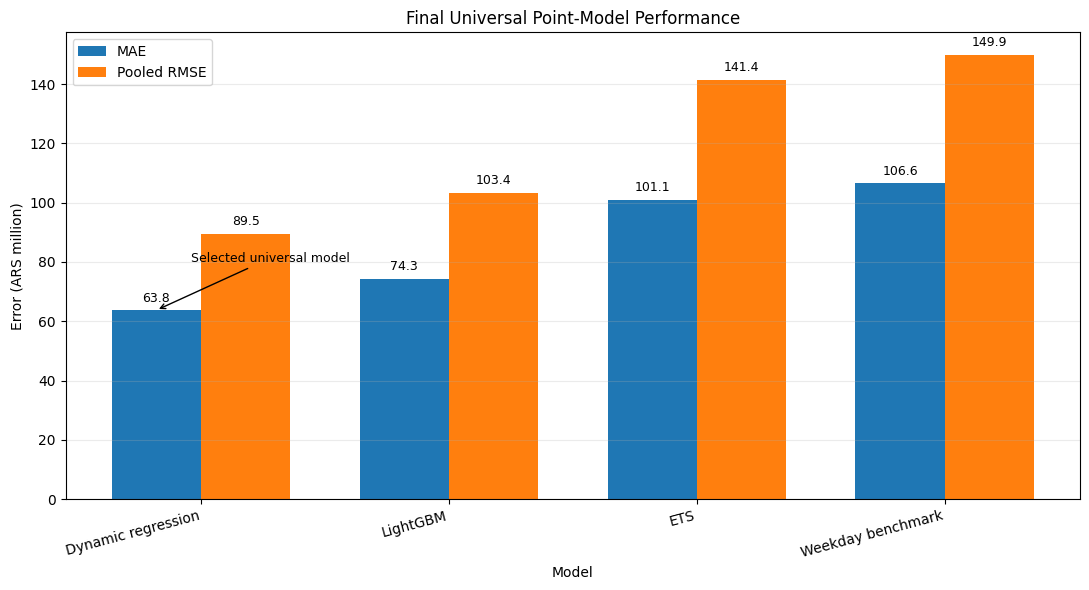

Saved table: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\08_final_universal_model_comparison_data.csv
Saved figure: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures\08_final_universal_model_comparison.png

Figure source data:


,display_name,mae,pooled_rmse,bias_percent,operational_role
0,Dynamic regression,63.750298,89.467831,0.491278,FINAL_UNIVERSAL_POINT_MODEL
1,LightGBM,74.316200,103.401250,0.582602,ML_CHALLENGER
2,ETS,101.062022,141.389217,-0.862182,STATISTICAL_BENCHMARK
3,Weekday benchmark,106.576212,149.940772,-3.801958,SIMPLE_BENCHMARK


In [10]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Prepare figure source data
# ---------------------------------------------------------------------

universal_roles = [
    "FINAL_UNIVERSAL_POINT_MODEL",
    "ML_CHALLENGER",
    "STATISTICAL_BENCHMARK",
    "SIMPLE_BENCHMARK",
]

figure_model_comparison = (
    dashboard_model_performance[
        dashboard_model_performance["operational_role"]
        .isin(universal_roles)
    ]
    .copy()
)

label_map = {
    "calendar_promotion_trend_arima011_errors":
        "Dynamic regression",
    "lightgbm_global_direct_relative_rolling56_l2":
        "LightGBM",
    "ets_log_damped_additive":
        "ETS",
    "historical_weekday_average":
        "Weekday benchmark",
}

figure_model_comparison["display_name"] = (
    figure_model_comparison["model_name"]
    .map(label_map)
)

figure_model_comparison = (
    figure_model_comparison
    .sort_values("mae")
    .reset_index(drop=True)
)

assert len(figure_model_comparison) == 4
assert figure_model_comparison["display_name"].notna().all()
assert figure_model_comparison["observations"].eq(560).all()

# ---------------------------------------------------------------------
# Save figure source table
# ---------------------------------------------------------------------

figure_model_comparison_data_path = (
    PROCESSED_DIR
    / "08_final_universal_model_comparison_data.csv"
)

figure_model_comparison[
    [
        "display_name",
        "model_name",
        "operational_role",
        "observations",
        "bias_percent",
        "mae",
        "pooled_rmse",
    ]
].to_csv(
    figure_model_comparison_data_path,
    index=False,
)

assert figure_model_comparison_data_path.exists()

# ---------------------------------------------------------------------
# Create final comparison figure
# ---------------------------------------------------------------------

x = np.arange(len(figure_model_comparison))
bar_width = 0.36

fig, ax = plt.subplots(figsize=(11, 6))

mae_bars = ax.bar(
    x - bar_width / 2,
    figure_model_comparison["mae"],
    width=bar_width,
    label="MAE",
)

rmse_bars = ax.bar(
    x + bar_width / 2,
    figure_model_comparison["pooled_rmse"],
    width=bar_width,
    label="Pooled RMSE",
)

ax.set_title(
    "Final Universal Point-Model Performance"
)
ax.set_ylabel("Error (ARS million)")
ax.set_xlabel("Model")

ax.set_xticks(x)
ax.set_xticklabels(
    figure_model_comparison["display_name"],
    rotation=15,
    ha="right",
)

ax.legend()

# Add metric labels above bars.
for bars in [mae_bars, rmse_bars]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.1f}",
            xy=(
                bar.get_x() + bar.get_width() / 2,
                height,
            ),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

# Add a short annotation identifying the operational winner.
selected_idx = figure_model_comparison.index[
    figure_model_comparison["operational_role"]
    .eq("FINAL_UNIVERSAL_POINT_MODEL")
][0]

ax.annotate(
    "Selected universal model",
    xy=(
        selected_idx - bar_width / 2,
        figure_model_comparison.loc[selected_idx, "mae"],
    ),
    xytext=(25, 35),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->"},
    fontsize=9,
)

ax.grid(
    axis="y",
    alpha=0.25,
)

fig.tight_layout()

# ---------------------------------------------------------------------
# Save immediately
# ---------------------------------------------------------------------

final_model_comparison_figure_path = (
    FIGURES_DIR
    / "08_final_universal_model_comparison.png"
)

fig.savefig(
    final_model_comparison_figure_path,
    dpi=300,
    bbox_inches="tight",
)

assert final_model_comparison_figure_path.exists()

plt.show()

print(f"Saved table: {figure_model_comparison_data_path}")
print(f"Saved figure: {final_model_comparison_figure_path}")

print("\nFigure source data:")
display(
    figure_model_comparison[
        [
            "display_name",
            "mae",
            "pooled_rmse",
            "bias_percent",
            "operational_role",
        ]
    ]
)

## 8. Review Final Portfolio Figure Candidates

Notebook 08 should avoid recreating visualizations that were already validated in previous notebooks.

Together with the final universal-model comparison created above, Notebook 07 already contains the principal visual evidence required to communicate:

* probabilistic calibration;
* liquidity-policy cost sensitivity;
* five-day operational reserve performance.

The following validated figures are reviewed before defining the final README and dashboard figure set.


,figure_role,filename,file_exists,file_size_bytes
0,probabilistic_calibration,07_prequential_quantile_calibration.png,True,235405
1,liquidity_cost_sensitivity,07_liquidity_policy_cost_sensitivity.png,True,298583
2,five_day_operational_reserve,07_five_day_operational_liquidity_recommendati...,True,449685



PROBABILISTIC CALIBRATION


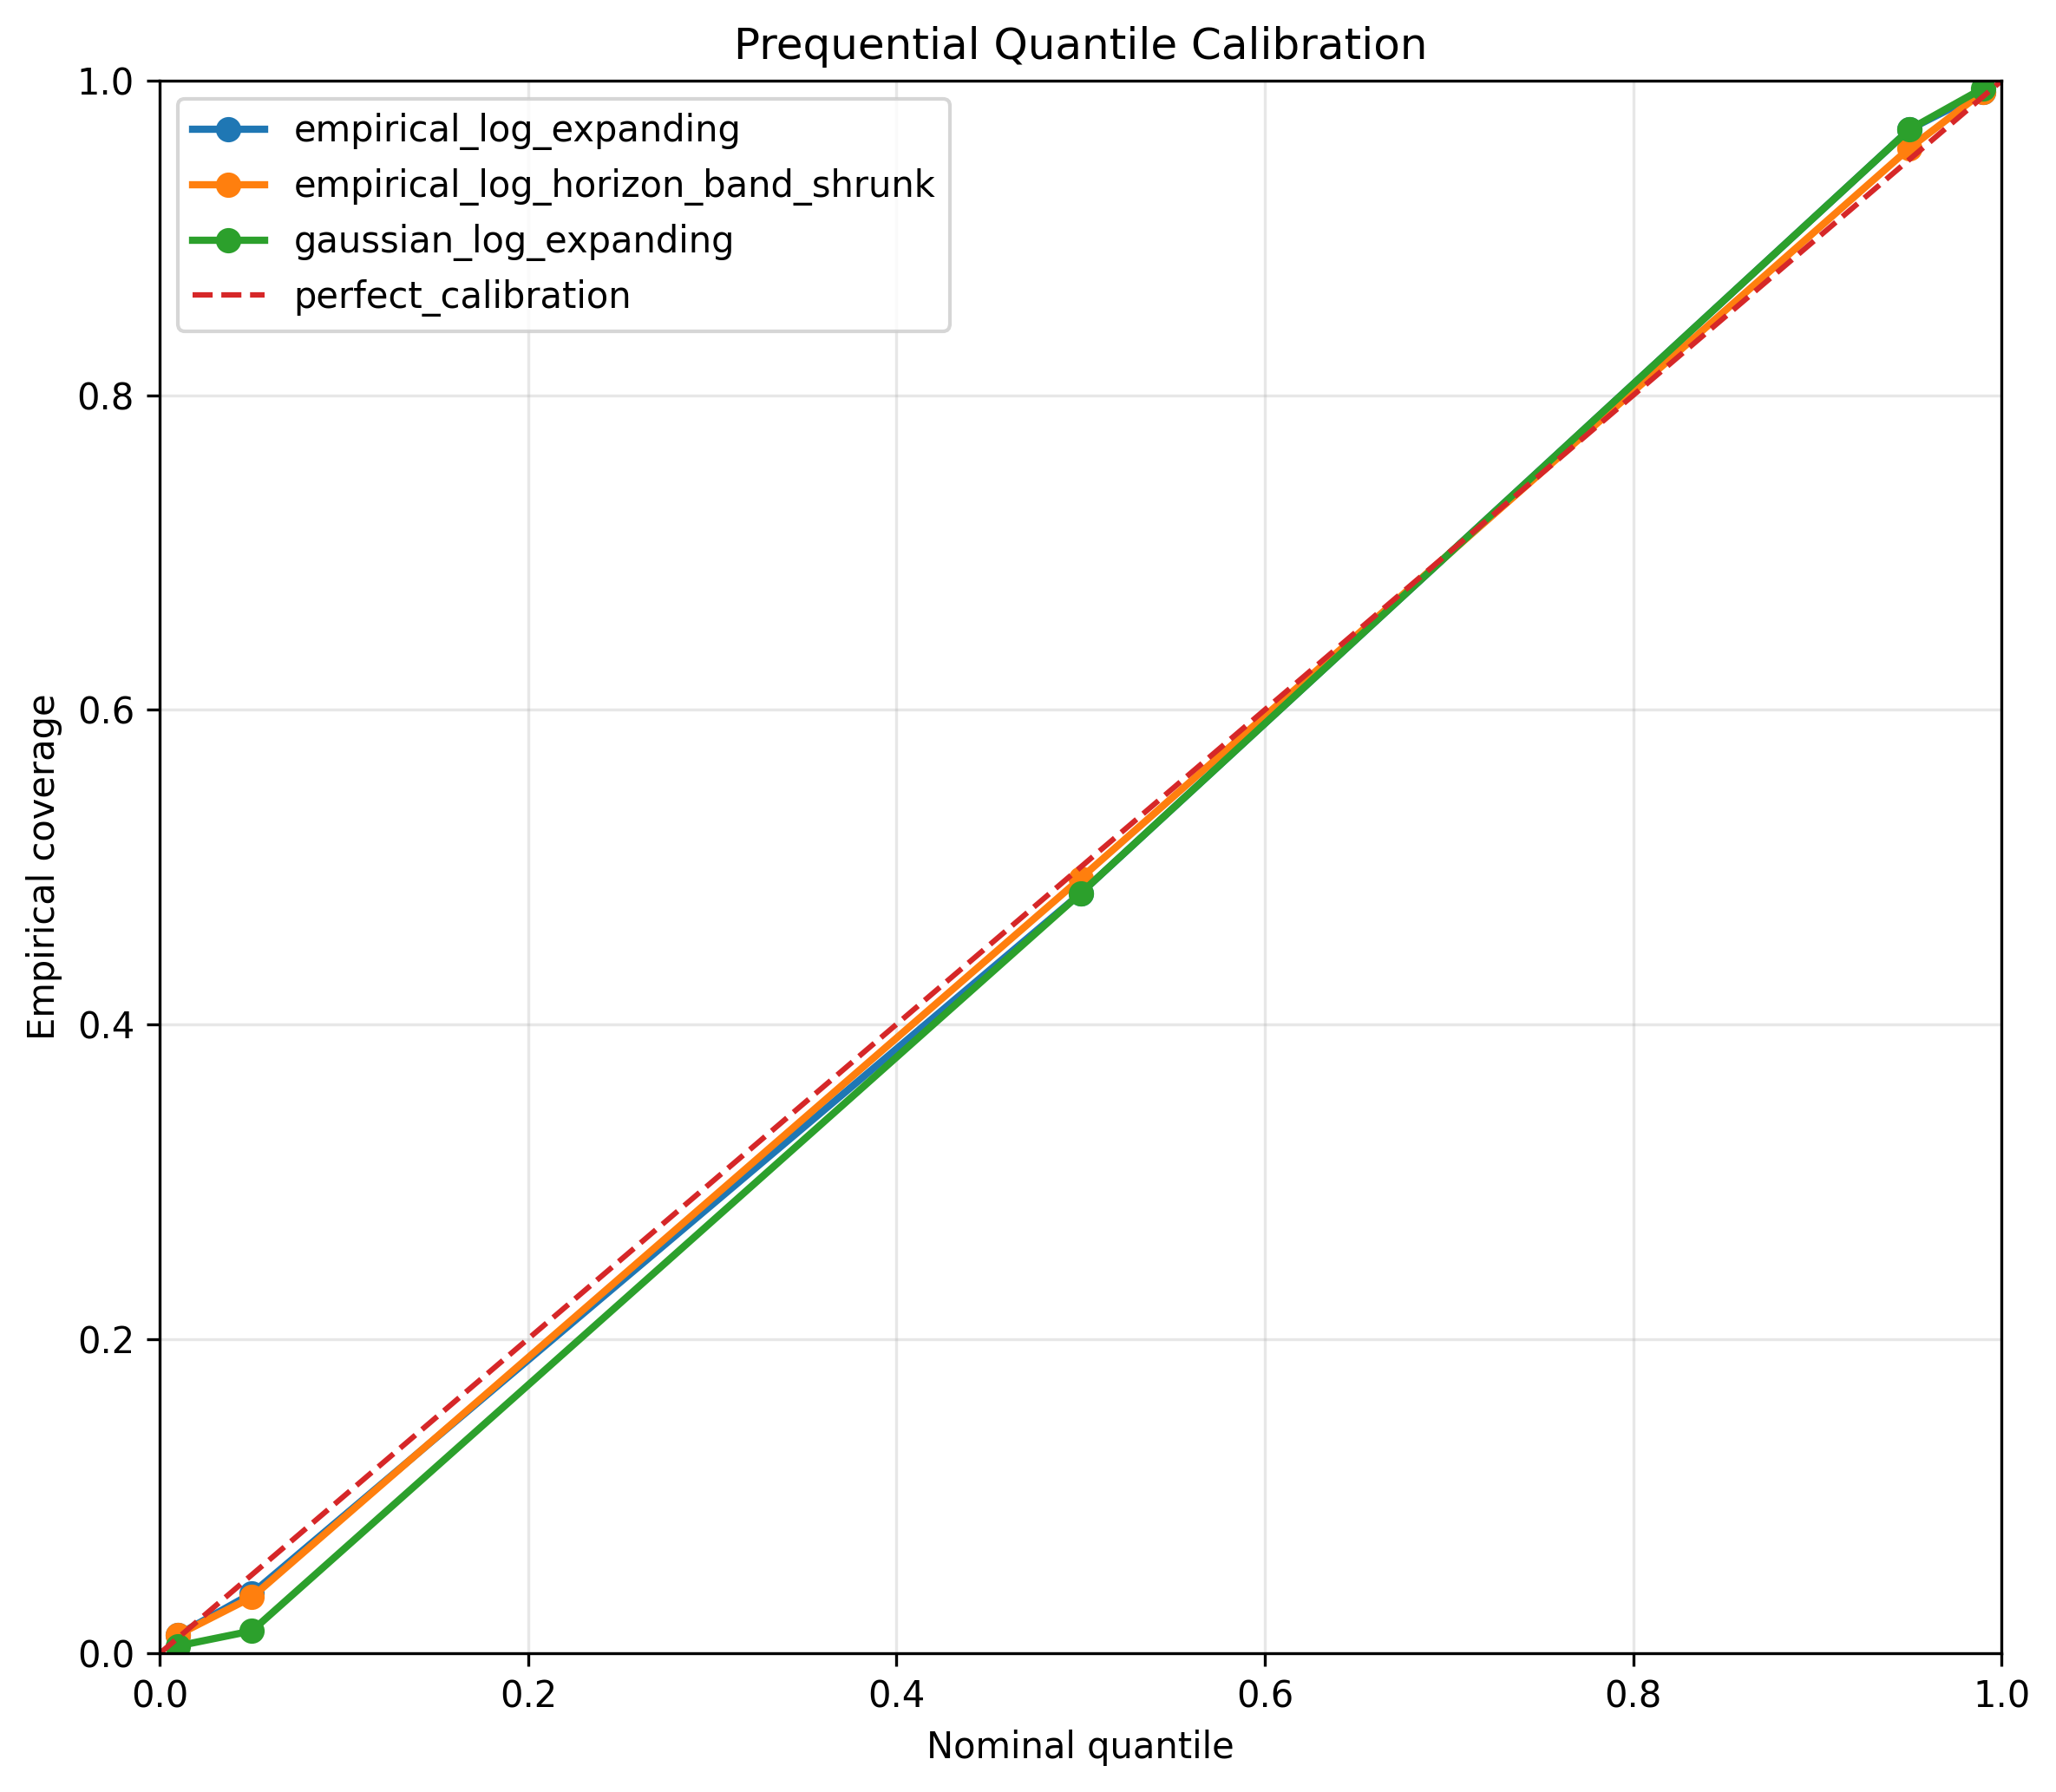


LIQUIDITY COST SENSITIVITY


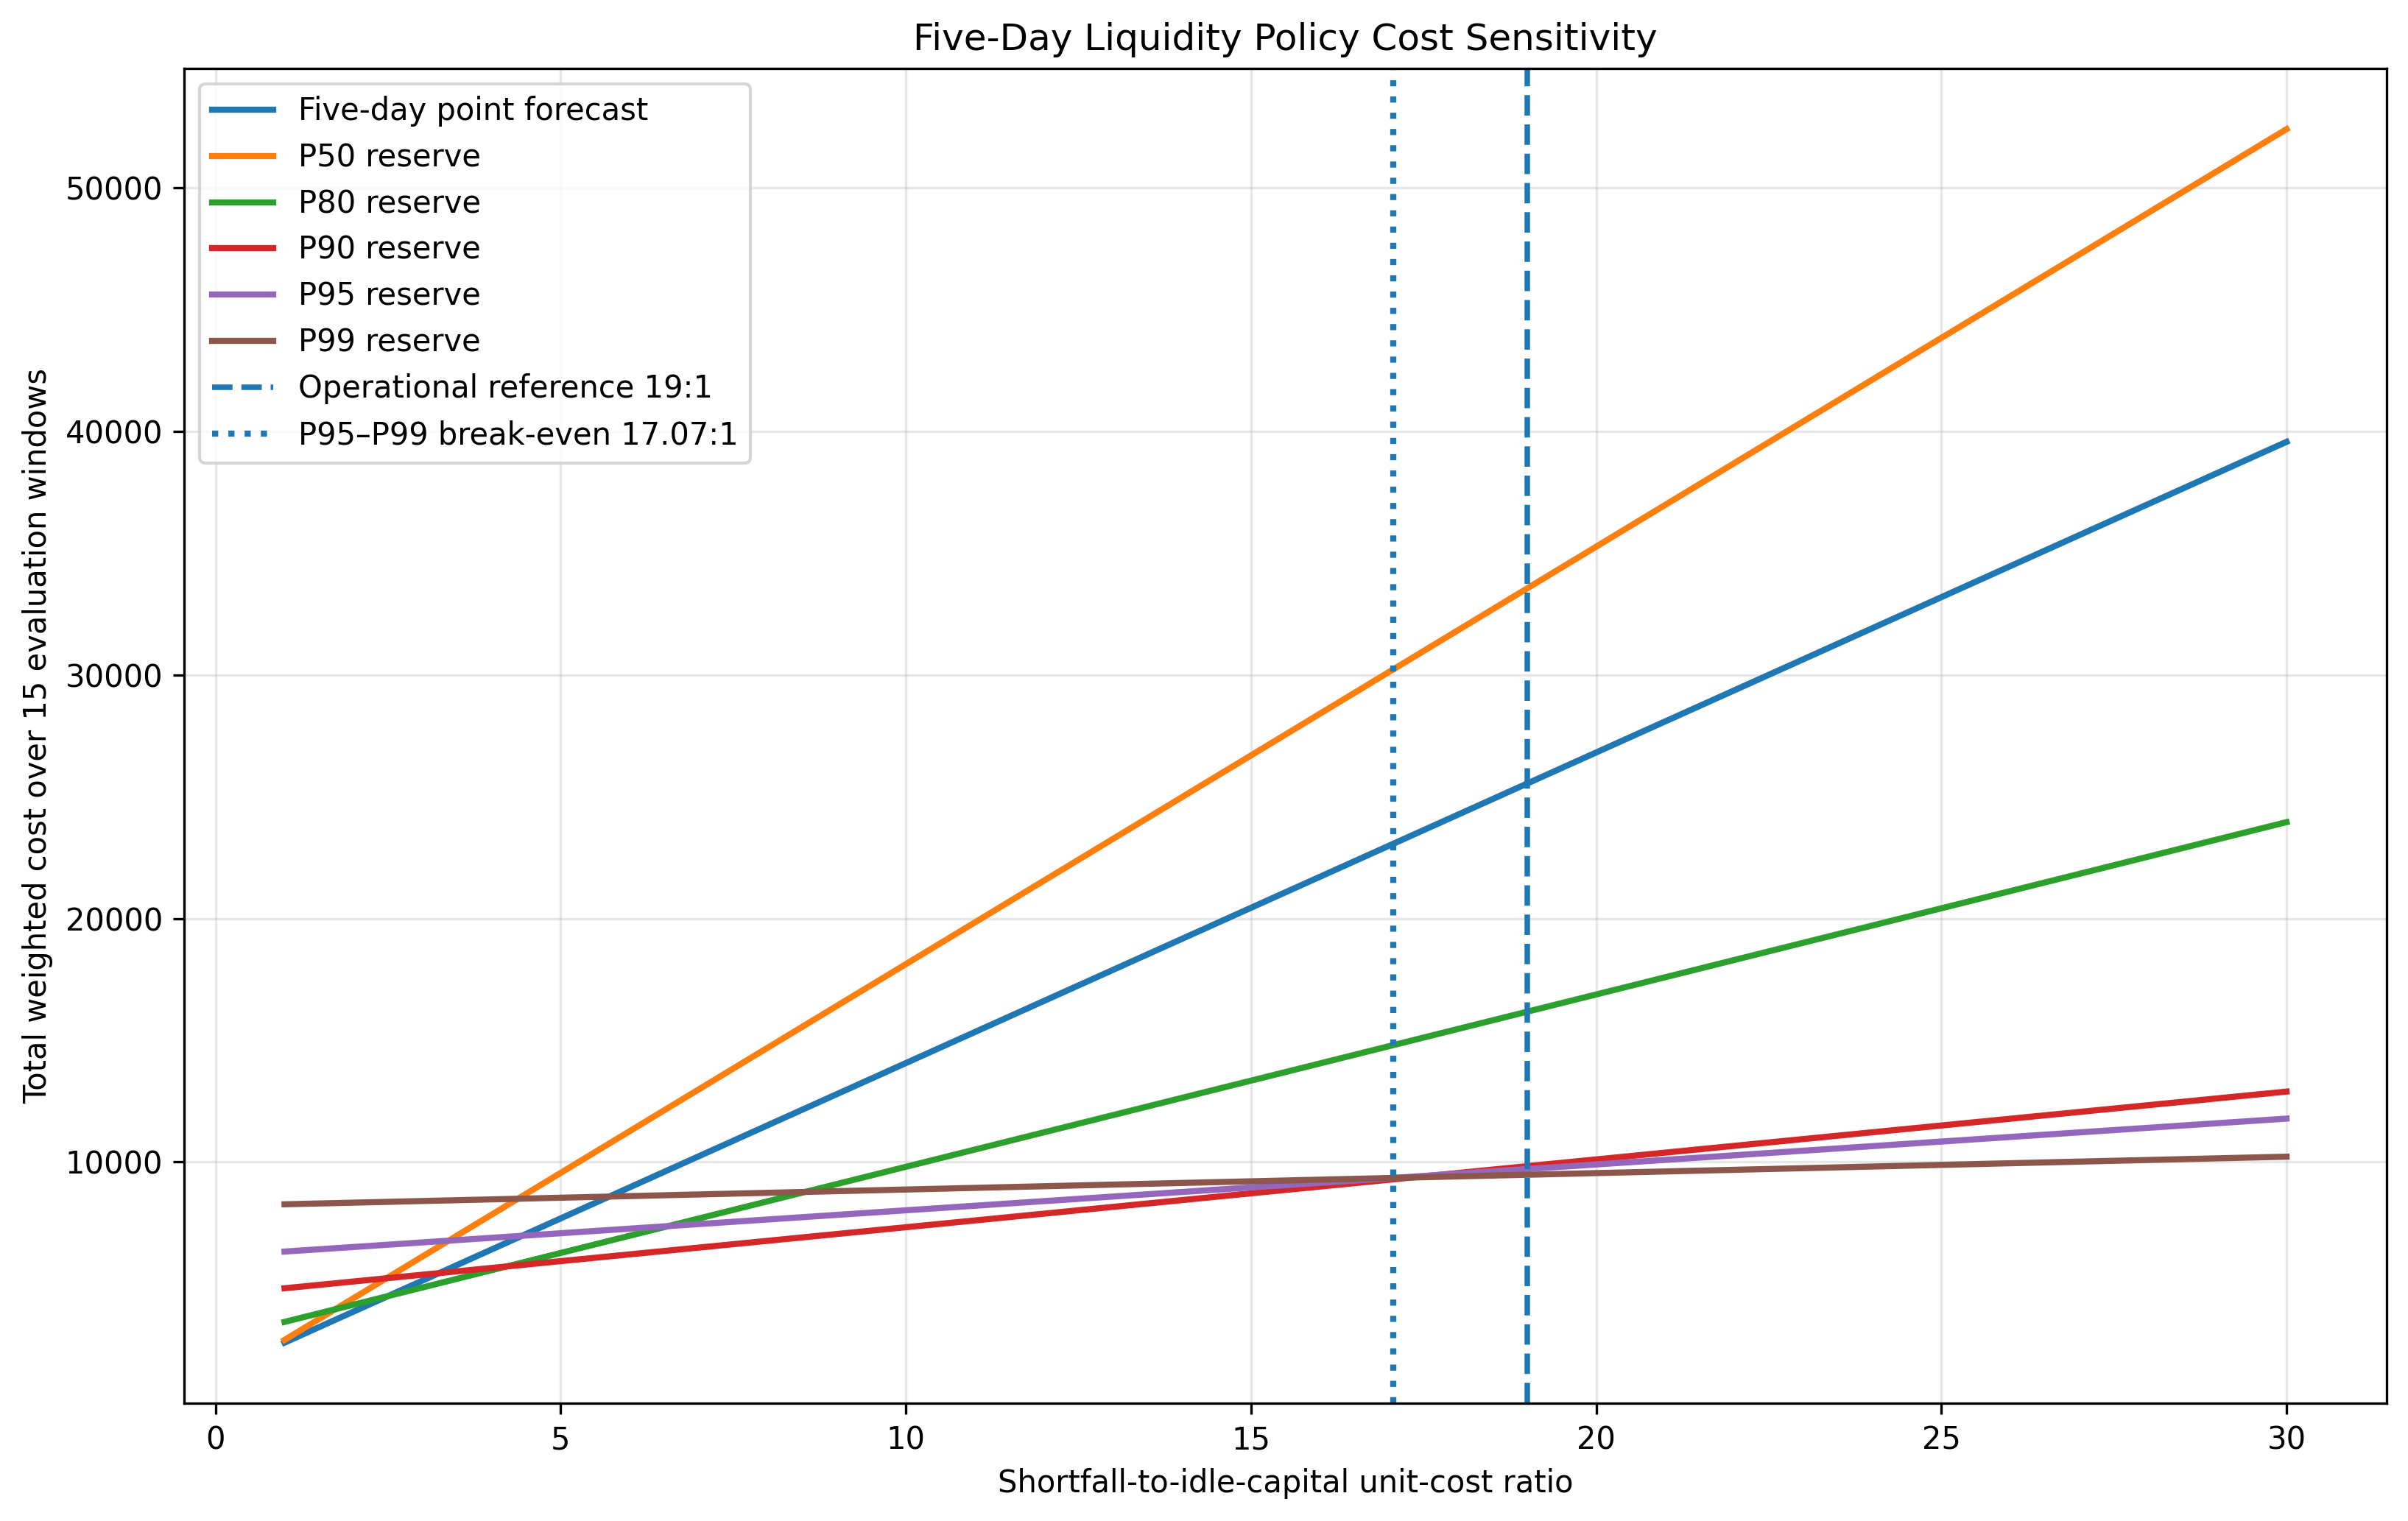


FIVE DAY OPERATIONAL RESERVE


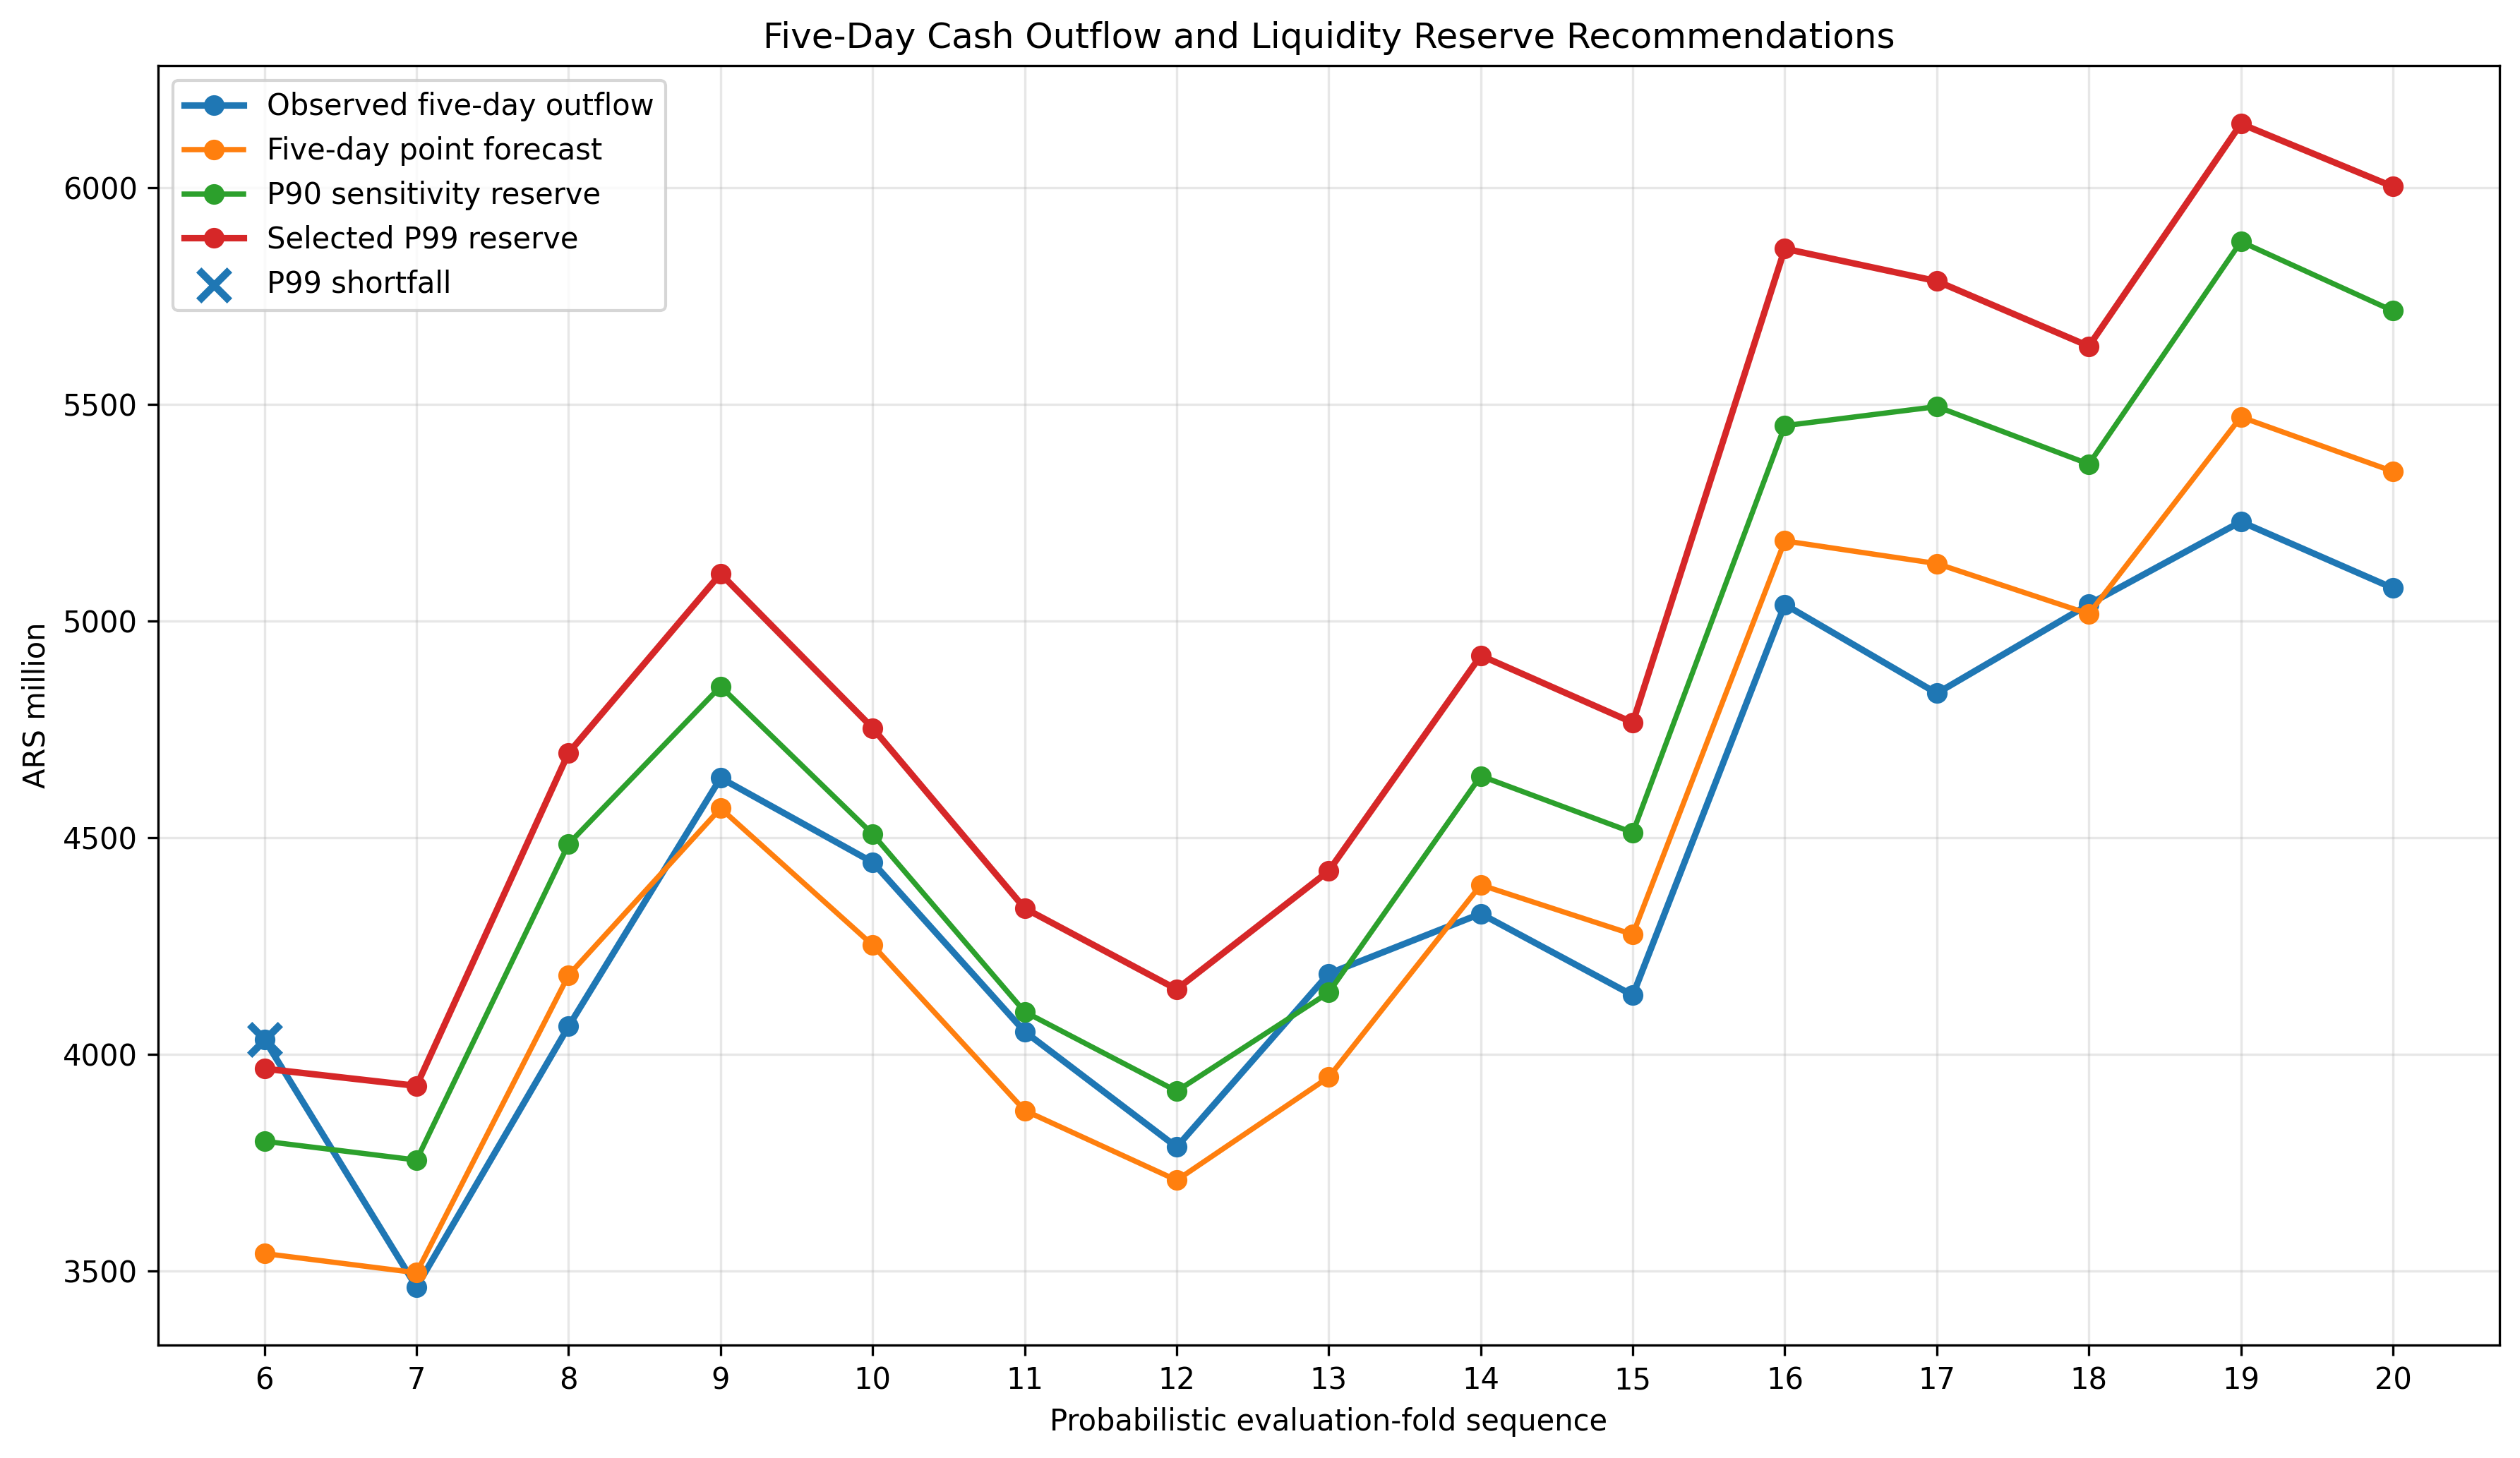

In [11]:
from IPython.display import Image, display

# ---------------------------------------------------------------------
# Final figure candidates inherited from Notebook 07
# ---------------------------------------------------------------------

final_figure_candidates = {
    "probabilistic_calibration":
        FIGURES_DIR / "07_prequential_quantile_calibration.png",

    "liquidity_cost_sensitivity":
        FIGURES_DIR / "07_liquidity_policy_cost_sensitivity.png",

    "five_day_operational_reserve":
        FIGURES_DIR / "07_five_day_operational_liquidity_recommendations.png",
}

figure_candidate_validation = pd.DataFrame(
    [
        {
            "figure_role": role,
            "filename": path.name,
            "file_exists": path.exists(),
            "file_size_bytes": (
                path.stat().st_size if path.exists() else np.nan
            ),
        }
        for role, path in final_figure_candidates.items()
    ]
)

display(figure_candidate_validation)

assert figure_candidate_validation["file_exists"].all()
assert (
    figure_candidate_validation["file_size_bytes"] > 0
).all()

# ---------------------------------------------------------------------
# Display each validated figure for visual review
# ---------------------------------------------------------------------

for role, path in final_figure_candidates.items():
    print("\n" + "=" * 80)
    print(role.upper().replace("_", " "))
    print("=" * 80)

    display(
        Image(
            filename=str(path),
            width=1000,
        )
    )

## 9. Recover Policy-Sensitivity and Analyst-in-the-Loop Fields

The final dashboard must preserve the distinction between the model forecast, probabilistic reserve, analyst adjustment, final reserve, and observed cash outflow.

It must also communicate that the selected P99 policy is conditional on the assumed shortfall-to-idle-capital cost ratio rather than universally optimal.

This section inspects the frozen Notebook 07 policy and operational artifacts before creating the final dashboard views. No policy metrics or reserve values are recomputed.


In [12]:
# ---------------------------------------------------------------------
# Recover policy-sensitivity artifacts
# ---------------------------------------------------------------------

policy_metrics_path = (
    PROCESSED_DIR / "07_liquidity_policy_metrics.csv"
)

policy_regions_path = (
    PROCESSED_DIR / "07_liquidity_policy_optimal_regions.csv"
)

policy_roles_path = (
    PROCESSED_DIR / "07_liquidity_policy_role_registry.csv"
)

for path in [
    policy_metrics_path,
    policy_regions_path,
    policy_roles_path,
]:
    assert path.exists(), f"Missing policy artifact: {path}"

liquidity_policy_metrics = pd.read_csv(
    policy_metrics_path
)

liquidity_policy_optimal_regions = pd.read_csv(
    policy_regions_path
)

liquidity_policy_roles = pd.read_csv(
    policy_roles_path
)

# ---------------------------------------------------------------------
# Inspect schemas needed for final dashboard consolidation
# ---------------------------------------------------------------------

print("Operational recommendation columns:")
print(operational_recommendations.columns.tolist())

print("\nLiquidity-policy metrics:")
display(liquidity_policy_metrics)

print("\nLiquidity-policy optimal regions:")
display(liquidity_policy_optimal_regions)

print("\nLiquidity-policy role registry:")
display(liquidity_policy_roles)

# ---------------------------------------------------------------------
# Identify analyst-related fields already preserved in Notebook 07
# ---------------------------------------------------------------------

analyst_columns = [
    col
    for col in operational_recommendations.columns
    if any(
        term in col.lower()
        for term in [
            "analyst",
            "adjustment",
            "reason",
            "final_reserve",
            "observed_outflow",
        ]
    )
]

print("\nAnalyst-in-the-loop related fields:")
print(analyst_columns)

if analyst_columns:
    display(
        operational_recommendations[
            analyst_columns
        ].head()
    )

Operational recommendation columns:
['fold_id', 'fold_sequence', 'forecast_origin', 'target_start', 'target_end', 'actual_5d_total', 'point_5d_total', 'reserve_p50', 'reserve_p80', 'reserve_p90', 'reserve_p95', 'reserve_p99', 'calibration_folds', 'available_contiguous_blocks', 'simulation_count', 'joint_method_id', 'daily_probabilistic_method', 'selected_policy_id', 'selected_policy_quantile', 'sensitivity_policy_id', 'model_selected_reserve', 'sensitivity_reserve', 'analyst_adjustment', 'adjustment_reason', 'final_reserve', 'observed_outflow', 'shortfall_amount', 'idle_capital_amount', 'shortfall_event', 'service_success', 'operational_cost_ratio_shortfall_to_idle', 'shortfall_cost', 'idle_capital_cost', 'total_operational_cost']

Liquidity-policy metrics:


,scenario_id,scenario_label,scenario_role,cost_ratio_shortfall_to_idle,optimal_quantile,reserve_policy_id,policy_id,policy_label,policy_role,nominal_quantile,...,mean_idle_capital,maximum_idle_capital,total_shortfall_cost,total_idle_capital_cost,total_cost,mean_cost_per_window,maximum_window_cost,service_level,shortfall_rate,matches_scenario_theoretical_policy
0,balanced_reference,Balanced reference,reference,1.0,0.50,reserve_p50,point_forecast_sum,Five-day point forecast,non_probabilistic_benchmark,NaN,...,87.667051,299.343068,1274.809950,1315.005758,2589.815708,172.654381,493.950894,0.533333,0.466667,False
1,balanced_reference,Balanced reference,reference,1.0,0.50,reserve_p50,reserve_p50,P50 reserve,probabilistic_policy,0.50,...,65.949848,255.641110,1713.455293,989.247720,2702.703014,180.180201,540.871642,0.466667,0.533333,True
2,balanced_reference,Balanced reference,reference,1.0,0.50,reserve_p50,reserve_p80,P80 reserve,probabilistic_policy,0.80,...,182.257644,466.386357,707.278370,2733.864664,3441.143034,229.409536,466.386357,0.733333,0.266667,False
3,balanced_reference,Balanced reference,reference,1.0,0.50,reserve_p50,reserve_p90,P90 reserve,probabilistic_policy,0.90,...,302.885213,661.652777,278.352587,4543.278198,4821.630785,321.442052,661.652777,0.866667,0.133333,False
4,balanced_reference,Balanced reference,reference,1.0,0.50,reserve_p50,reserve_p95,P95 reserve,probabilistic_policy,0.95,...,409.314717,828.384024,188.157062,6139.720754,6327.877816,421.858521,828.384024,0.933333,0.066667,False
5,balanced_reference,Balanced reference,reference,1.0,0.50,reserve_p50,reserve_p99,P99 reserve,probabilistic_policy,0.99,...,546.713059,951.197317,67.387240,8200.695892,8268.083131,551.205542,951.197317,0.933333,0.066667,False
6,extreme_shortfall_priority,Extreme shortfall priority,stress_sensitivity,99.0,0.99,reserve_p99,point_forecast_sum,Five-day point forecast,non_probabilistic_benchmark,NaN,...,87.667051,299.343068,126206.185062,1315.005758,127521.190821,8501.412721,48901.138528,0.533333,0.466667,False
7,extreme_shortfall_priority,Extreme shortfall priority,stress_sensitivity,99.0,0.99,reserve_p99,reserve_p50,P50 reserve,probabilistic_policy,0.50,...,65.949848,255.641110,169632.074054,989.247720,170621.321774,11374.754785,53546.292563,0.466667,0.533333,False
8,extreme_shortfall_priority,Extreme shortfall priority,stress_sensitivity,99.0,0.99,reserve_p99,reserve_p80,P80 reserve,probabilistic_policy,0.80,...,182.257644,466.386357,70020.558636,2733.864664,72754.423300,4850.294887,38595.114842,0.733333,0.266667,False
9,extreme_shortfall_priority,Extreme shortfall priority,stress_sensitivity,99.0,0.99,reserve_p99,reserve_p90,P90 reserve,probabilistic_policy,0.90,...,302.885213,661.652777,27556.906111,4543.278198,32100.184309,2140.012287,23246.793302,0.866667,0.133333,False



Liquidity-policy optimal regions:


,winner_region_id,empirical_winner_policy_id,empirical_winner_policy_label,empirical_winner_nominal_quantile,minimum_cost_ratio,maximum_cost_ratio,minimum_theoretical_quantile,maximum_theoretical_quantile,grid_points
0,1,point_forecast_sum,Five-day point forecast,NaN,1.0,2.5,0.500000,0.714286,16
1,2,reserve_p80,P80 reserve,0.80,2.6,4.2,0.722222,0.807692,17
2,3,reserve_p90,P90 reserve,0.90,4.3,17.3,0.811321,0.945355,131
3,4,reserve_p99,P99 reserve,0.99,17.4,100.0,0.945652,0.990099,827



Liquidity-policy role registry:


,policy_id,policy_label,reserve_column,nominal_quantile,policy_role,operational_status,empirical_optimal_minimum_cost_ratio,empirical_optimal_maximum_cost_ratio
0,point_forecast_sum,Five-day point forecast,point_5d_total,NaN,non_probabilistic_benchmark,NON_PROBABILISTIC_BENCHMARK,1.0,2.5
1,reserve_p50,P50 reserve,reserve_p50,0.50,probabilistic_policy,BALANCED_REFERENCE,NaN,NaN
2,reserve_p80,P80 reserve,reserve_p80,0.80,probabilistic_policy,LOWER_COST_SENSITIVITY,2.6,4.2
3,reserve_p90,P90 reserve,reserve_p90,0.90,probabilistic_policy,RETAINED_COST_SENSITIVITY_CHALLENGER,4.3,17.3
4,reserve_p95,P95 reserve,reserve_p95,0.95,probabilistic_policy,THEORETICAL_19_TO_1_REFERENCE_NOT_EMPIRICAL_WI...,NaN,NaN
5,reserve_p99,P99 reserve,reserve_p99,0.99,probabilistic_policy,SELECTED_OPERATIONAL_POLICY,17.4,100.0



Analyst-in-the-loop related fields:
['analyst_adjustment', 'adjustment_reason', 'final_reserve', 'observed_outflow']


,analyst_adjustment,adjustment_reason,final_reserve,observed_outflow
0,0.0,NO_ADJUSTMENT_IN_BACKTEST,3966.456760,4033.844
1,0.0,NO_ADJUSTMENT_IN_BACKTEST,3926.834042,3462.541
2,0.0,NO_ADJUSTMENT_IN_BACKTEST,4695.277296,4064.120
3,0.0,NO_ADJUSTMENT_IN_BACKTEST,5108.802322,4637.375
4,0.0,NO_ADJUSTMENT_IN_BACKTEST,4752.752159,4442.830


## 10. Build Final Policy-Sensitivity and Analyst-in-the-Loop Tables

The selected reserve policy is conditional on the relative cost assigned to liquidity shortfalls versus idle capital.

Empirical cost sensitivity shows distinct operating regions:

* the five-day point forecast is favored at very low shortfall-cost ratios;
* P80 becomes preferable as shortfall costs increase;
* P90 is the main sensitivity policy for intermediate cost asymmetry;
* P99 becomes the empirical winner once the shortfall-to-idle-capital ratio exceeds approximately 17.4:1.

Under the illustrative 19:1 operating scenario, P95 is the theoretically implied quantile, but P99 achieves the lowest observed cost in the finite backtest sample.

The operational dataset also preserves an explicit analyst-in-the-loop structure. Analyst adjustments were not applied during backtesting, preventing manual intervention from introducing hidden future information.


In [13]:
# ---------------------------------------------------------------------
# Build compact policy-sensitivity table for final communication
# ---------------------------------------------------------------------

final_policy_ids = [
    "reserve_p90",
    "reserve_p95",
    "reserve_p99",
]

# Operational 19:1 scenario metrics.
policy_sensitivity = (
    liquidity_policy_metrics[
        liquidity_policy_metrics["scenario_id"]
        .eq("operational_base_19_to_1")
        &
        liquidity_policy_metrics["policy_id"]
        .isin(final_policy_ids)
    ]
    .copy()
)

# Add frozen policy roles and empirical optimal regions.
policy_role_columns = [
    "policy_id",
    "operational_status",
    "empirical_optimal_minimum_cost_ratio",
    "empirical_optimal_maximum_cost_ratio",
]

policy_sensitivity = policy_sensitivity.merge(
    liquidity_policy_roles[policy_role_columns],
    on="policy_id",
    how="left",
    validate="one_to_one",
)

# Keep only final dashboard fields.
policy_sensitivity = policy_sensitivity[
    [
        "policy_id",
        "policy_label",
        "nominal_quantile",
        "operational_status",
        "empirical_optimal_minimum_cost_ratio",
        "empirical_optimal_maximum_cost_ratio",
        "service_level",
        "shortfall_rate",
        "mean_idle_capital",
        "total_shortfall_cost",
        "total_idle_capital_cost",
        "total_cost",
        "matches_scenario_theoretical_policy",
    ]
].copy()

policy_order = {
    "reserve_p90": 1,
    "reserve_p95": 2,
    "reserve_p99": 3,
}

policy_sensitivity["display_order"] = (
    policy_sensitivity["policy_id"].map(policy_order)
)

policy_sensitivity = (
    policy_sensitivity
    .sort_values("display_order")
    .drop(columns="display_order")
    .reset_index(drop=True)
)

# ---------------------------------------------------------------------
# Validation
# ---------------------------------------------------------------------

policy_sensitivity_validation = pd.DataFrame(
    {
        "check": [
            "policy_rows",
            "policies",
            "p90_minimum_cost_ratio",
            "p90_maximum_cost_ratio",
            "p95_is_theoretical_reference",
            "p95_has_no_empirical_region",
            "p99_minimum_cost_ratio",
            "p99_selected_operational_policy",
            "p99_cost_lower_than_p95_at_19_to_1",
            "p99_cost_lower_than_p90_at_19_to_1",
        ],
        "observed": [
            len(policy_sensitivity),
            policy_sensitivity["policy_id"].tolist(),

            policy_sensitivity.loc[
                policy_sensitivity["policy_id"].eq("reserve_p90"),
                "empirical_optimal_minimum_cost_ratio",
            ].iloc[0],

            policy_sensitivity.loc[
                policy_sensitivity["policy_id"].eq("reserve_p90"),
                "empirical_optimal_maximum_cost_ratio",
            ].iloc[0],

            policy_sensitivity.loc[
                policy_sensitivity["policy_id"].eq("reserve_p95"),
                "matches_scenario_theoretical_policy",
            ].iloc[0],

            policy_sensitivity.loc[
                policy_sensitivity["policy_id"].eq("reserve_p95"),
                [
                    "empirical_optimal_minimum_cost_ratio",
                    "empirical_optimal_maximum_cost_ratio",
                ],
            ].isna().all(axis=None),

            policy_sensitivity.loc[
                policy_sensitivity["policy_id"].eq("reserve_p99"),
                "empirical_optimal_minimum_cost_ratio",
            ].iloc[0],

            (
                policy_sensitivity.loc[
                    policy_sensitivity["policy_id"].eq("reserve_p99"),
                    "operational_status",
                ].iloc[0]
                == "SELECTED_OPERATIONAL_POLICY"
            ),

            (
                policy_sensitivity.loc[
                    policy_sensitivity["policy_id"].eq("reserve_p99"),
                    "total_cost",
                ].iloc[0]
                <
                policy_sensitivity.loc[
                    policy_sensitivity["policy_id"].eq("reserve_p95"),
                    "total_cost",
                ].iloc[0]
            ),

            (
                policy_sensitivity.loc[
                    policy_sensitivity["policy_id"].eq("reserve_p99"),
                    "total_cost",
                ].iloc[0]
                <
                policy_sensitivity.loc[
                    policy_sensitivity["policy_id"].eq("reserve_p90"),
                    "total_cost",
                ].iloc[0]
            ),
        ],
        "expected": [
            3,
            ["reserve_p90", "reserve_p95", "reserve_p99"],
            4.3,
            17.3,
            True,
            True,
            17.4,
            True,
            True,
            True,
        ],
    }
)

float_rows = [2, 3, 6]

for idx in float_rows:
    policy_sensitivity_validation.loc[idx, "status"] = (
        "PASS"
        if np.isclose(
            float(policy_sensitivity_validation.loc[idx, "observed"]),
            float(policy_sensitivity_validation.loc[idx, "expected"]),
            atol=1e-8,
        )
        else "FAIL"
    )

for idx in policy_sensitivity_validation.index.difference(float_rows):
    policy_sensitivity_validation.loc[idx, "status"] = (
        "PASS"
        if str(policy_sensitivity_validation.loc[idx, "observed"])
        == str(policy_sensitivity_validation.loc[idx, "expected"])
        else "FAIL"
    )

assert (
    policy_sensitivity_validation["status"] == "PASS"
).all()

# ---------------------------------------------------------------------
# Save immediately
# ---------------------------------------------------------------------

policy_sensitivity_path = (
    PROCESSED_DIR / "08_dashboard_policy_sensitivity.csv"
)

policy_sensitivity.to_csv(
    policy_sensitivity_path,
    index=False,
)

assert policy_sensitivity_path.exists()

print(f"Saved: {policy_sensitivity_path}")

display(policy_sensitivity_validation)

print("\nFinal policy-sensitivity table:")
display(policy_sensitivity)

Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\08_dashboard_policy_sensitivity.csv


,check,observed,expected,status
0,policy_rows,3,3,PASS
1,policies,"[reserve_p90, reserve_p95, reserve_p99]","[reserve_p90, reserve_p95, reserve_p99]",PASS
2,p90_minimum_cost_ratio,4.3,4.3,PASS
3,p90_maximum_cost_ratio,17.3,17.3,PASS
4,p95_is_theoretical_reference,True,True,PASS
5,p95_has_no_empirical_region,True,True,PASS
6,p99_minimum_cost_ratio,17.4,17.4,PASS
7,p99_selected_operational_policy,True,True,PASS
8,p99_cost_lower_than_p95_at_19_to_1,True,True,PASS
9,p99_cost_lower_than_p90_at_19_to_1,True,True,PASS



Final policy-sensitivity table:


,policy_id,policy_label,nominal_quantile,operational_status,empirical_optimal_minimum_cost_ratio,empirical_optimal_maximum_cost_ratio,service_level,shortfall_rate,mean_idle_capital,total_shortfall_cost,total_idle_capital_cost,total_cost,matches_scenario_theoretical_policy
0,reserve_p90,P90 reserve,0.90,RETAINED_COST_SENSITIVITY_CHALLENGER,4.3,17.3,0.866667,0.133333,302.885213,5288.699153,4543.278198,9831.977350,False
1,reserve_p95,P95 reserve,0.95,THEORETICAL_19_TO_1_REFERENCE_NOT_EMPIRICAL_WI...,NaN,NaN,0.933333,0.066667,409.314717,3574.984187,6139.720754,9714.704940,True
2,reserve_p99,P99 reserve,0.99,SELECTED_OPERATIONAL_POLICY,17.4,100.0,0.933333,0.066667,546.713059,1280.357554,8200.695892,9481.053446,False


In [14]:
# ---------------------------------------------------------------------
# Build analyst-in-the-loop dashboard table
# ---------------------------------------------------------------------

analyst_dashboard_columns = [
    "fold_id",
    "forecast_origin",
    "target_start",
    "target_end",
    "point_5d_total",
    "reserve_p99",
    "analyst_adjustment",
    "adjustment_reason",
    "final_reserve",
    "observed_outflow",
    "service_success",
]

missing_analyst_columns = [
    col for col in analyst_dashboard_columns
    if col not in operational_recommendations.columns
]

assert not missing_analyst_columns, (
    f"Missing analyst workflow columns: {missing_analyst_columns}"
)

analyst_in_loop_dashboard = (
    operational_recommendations[
        analyst_dashboard_columns
    ]
    .copy()
    .reset_index(drop=True)
)

# ---------------------------------------------------------------------
# Validation
# ---------------------------------------------------------------------

analyst_dashboard_validation = pd.DataFrame(
    {
        "check": [
            "rows",
            "analyst_adjustments_sum",
            "all_adjustments_zero",
            "adjustment_reason",
            "final_reserve_matches_model_p99",
            "successful_windows",
            "missing_values",
        ],
        "observed": [
            len(analyst_in_loop_dashboard),

            analyst_in_loop_dashboard[
                "analyst_adjustment"
            ].sum(),

            analyst_in_loop_dashboard[
                "analyst_adjustment"
            ].eq(0).all(),

            analyst_in_loop_dashboard[
                "adjustment_reason"
            ].unique().tolist(),

            np.allclose(
                analyst_in_loop_dashboard["final_reserve"],
                analyst_in_loop_dashboard["reserve_p99"],
            ),

            int(
                analyst_in_loop_dashboard[
                    "service_success"
                ].sum()
            ),

            int(
                analyst_in_loop_dashboard
                .isna()
                .sum()
                .sum()
            ),
        ],
        "expected": [
            15,
            0.0,
            True,
            ["NO_ADJUSTMENT_IN_BACKTEST"],
            True,
            14,
            0,
        ],
    }
)

analyst_dashboard_validation["status"] = np.where(
    analyst_dashboard_validation["observed"].astype(str)
    == analyst_dashboard_validation["expected"].astype(str),
    "PASS",
    "FAIL",
)

assert (
    analyst_dashboard_validation["status"] == "PASS"
).all()

# ---------------------------------------------------------------------
# Save immediately
# ---------------------------------------------------------------------

analyst_dashboard_path = (
    PROCESSED_DIR / "08_dashboard_analyst_in_the_loop.csv"
)

analyst_in_loop_dashboard.to_csv(
    analyst_dashboard_path,
    index=False,
)

assert analyst_dashboard_path.exists()

print(f"Saved: {analyst_dashboard_path}")

display(analyst_dashboard_validation)

print("\nAnalyst-in-the-loop dashboard table:")
display(analyst_in_loop_dashboard)

Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\08_dashboard_analyst_in_the_loop.csv


,check,observed,expected,status
0,rows,15,15,PASS
1,analyst_adjustments_sum,0.0,0.0,PASS
2,all_adjustments_zero,True,True,PASS
3,adjustment_reason,[NO_ADJUSTMENT_IN_BACKTEST],[NO_ADJUSTMENT_IN_BACKTEST],PASS
4,final_reserve_matches_model_p99,True,True,PASS
5,successful_windows,14,14,PASS
6,missing_values,0,0,PASS



Analyst-in-the-loop dashboard table:


,fold_id,forecast_origin,target_start,target_end,point_5d_total,reserve_p99,analyst_adjustment,adjustment_reason,final_reserve,observed_outflow,service_success
0,fold_06,2025-06-06,2025-06-07,2025-06-11,3539.893106,3966.456760,0.0,NO_ADJUSTMENT_IN_BACKTEST,3966.456760,4033.844,False
1,fold_07,2025-07-04,2025-07-05,2025-07-09,3495.557104,3926.834042,0.0,NO_ADJUSTMENT_IN_BACKTEST,3926.834042,3462.541,True
2,fold_08,2025-08-01,2025-08-02,2025-08-06,4182.230057,4695.277296,0.0,NO_ADJUSTMENT_IN_BACKTEST,4695.277296,4064.120,True
3,fold_09,2025-08-29,2025-08-30,2025-09-03,4567.323175,5108.802322,0.0,NO_ADJUSTMENT_IN_BACKTEST,5108.802322,4637.375,True
4,fold_10,2025-09-26,2025-09-27,2025-10-01,4251.649998,4752.752159,0.0,NO_ADJUSTMENT_IN_BACKTEST,4752.752159,4442.830,True
5,fold_11,2025-10-24,2025-10-25,2025-10-29,3870.053222,4336.637765,0.0,NO_ADJUSTMENT_IN_BACKTEST,4336.637765,4052.069,True
6,fold_12,2025-11-21,2025-11-22,2025-11-26,3709.113466,4149.763920,0.0,NO_ADJUSTMENT_IN_BACKTEST,4149.763920,3785.630,True
7,fold_13,2025-12-19,2025-12-20,2025-12-24,3946.775963,4422.777321,0.0,NO_ADJUSTMENT_IN_BACKTEST,4422.777321,4185.687,True
8,fold_14,2026-01-16,2026-01-17,2026-01-21,4390.559793,4919.974269,0.0,NO_ADJUSTMENT_IN_BACKTEST,4919.974269,4324.154,True
9,fold_15,2026-02-13,2026-02-14,2026-02-18,4276.177929,4765.139454,0.0,NO_ADJUSTMENT_IN_BACKTEST,4765.139454,4135.844,True


## 11. Consolidate README-Ready Final Results

The project has now completed all modeling, validation, uncertainty, and liquidity-policy stages.

This section consolidates the principal validated results into a single traceable table designed for:

* the final README;
* dashboard headline metrics;
* portfolio communication;
* interview discussion.

Every value below is recovered from frozen and validated artifacts. No metric is recomputed for model selection purposes.

The final business recommendation remains conditional on the illustrative 19:1 shortfall-to-idle-capital cost ratio and on the limited sample of 15 five-day evaluation windows.


In [15]:
# ---------------------------------------------------------------------
# Extract validated values for final communication
# ---------------------------------------------------------------------

selected_model_row = (
    dashboard_model_performance[
        dashboard_model_performance["selected_universal_model"]
    ]
    .iloc[0]
)

p95_row = (
    dashboard_quantile_performance[
        dashboard_quantile_performance["quantile_label"].eq("P95")
    ]
    .iloc[0]
)

p99_row = (
    dashboard_quantile_performance[
        dashboard_quantile_performance["quantile_label"].eq("P99")
    ]
    .iloc[0]
)

pi90_row = (
    dashboard_interval_performance[
        dashboard_interval_performance["interval_name"].eq("PI90")
    ]
    .iloc[0]
)

pi98_row = (
    dashboard_interval_performance[
        dashboard_interval_performance["interval_name"].eq("PI98")
    ]
    .iloc[0]
)

p99_policy_row = (
    policy_sensitivity[
        policy_sensitivity["policy_id"].eq("reserve_p99")
    ]
    .iloc[0]
)

# ---------------------------------------------------------------------
# Build compact README-ready result registry
# ---------------------------------------------------------------------

readme_ready_results = pd.DataFrame(
    [
        # Point forecasting
        {
            "section": "Point forecasting",
            "metric": "Final universal model",
            "value": selected_model_row["model_name"],
            "unit": "",
        },
        {
            "section": "Point forecasting",
            "metric": "MAE",
            "value": selected_model_row["mae"],
            "unit": "ARS million",
        },
        {
            "section": "Point forecasting",
            "metric": "Pooled RMSE",
            "value": selected_model_row["pooled_rmse"],
            "unit": "ARS million",
        },
        {
            "section": "Point forecasting",
            "metric": "Bias",
            "value": selected_model_row["bias_percent"],
            "unit": "%",
        },

        # Probabilistic forecasting
        {
            "section": "Probabilistic forecasting",
            "metric": "Daily probabilistic method",
            "value": selected_probabilistic_method,
            "unit": "",
        },
        {
            "section": "Probabilistic forecasting",
            "metric": "P95 empirical coverage",
            "value": p95_row["empirical_coverage"],
            "unit": "proportion",
        },
        {
            "section": "Probabilistic forecasting",
            "metric": "P99 empirical coverage",
            "value": p99_row["empirical_coverage"],
            "unit": "proportion",
        },
        {
            "section": "Probabilistic forecasting",
            "metric": "PI90 empirical coverage",
            "value": pi90_row["empirical_coverage"],
            "unit": "proportion",
        },
        {
            "section": "Probabilistic forecasting",
            "metric": "PI98 empirical coverage",
            "value": pi98_row["empirical_coverage"],
            "unit": "proportion",
        },

        # Five-day liquidity
        {
            "section": "Liquidity policy",
            "metric": "Joint five-day method",
            "value": final_operational_kpis.loc[
                0, "joint_five_day_method"
            ],
            "unit": "",
        },
        {
            "section": "Liquidity policy",
            "metric": "Funding lead time",
            "value": final_operational_kpis.loc[
                0, "funding_lead_time_days"
            ],
            "unit": "days",
        },
        {
            "section": "Liquidity policy",
            "metric": "Selected reserve policy",
            "value": final_operational_kpis.loc[
                0, "selected_policy"
            ],
            "unit": "",
        },
        {
            "section": "Liquidity policy",
            "metric": "Illustrative shortfall-to-idle cost ratio",
            "value": final_operational_kpis.loc[
                0, "operational_cost_ratio"
            ],
            "unit": "ratio",
        },
        {
            "section": "Liquidity policy",
            "metric": "P95-P99 break-even ratio",
            "value": final_operational_kpis.loc[
                0, "p95_p99_break_even_ratio"
            ],
            "unit": "ratio",
        },
        {
            "section": "Liquidity policy",
            "metric": "Five-day evaluation windows",
            "value": final_operational_kpis.loc[
                0, "evaluation_windows"
            ],
            "unit": "windows",
        },
        {
            "section": "Liquidity policy",
            "metric": "Observed service level",
            "value": final_operational_kpis.loc[
                0, "service_level"
            ],
            "unit": "proportion",
        },
        {
            "section": "Liquidity policy",
            "metric": "Shortfall windows",
            "value": final_operational_kpis.loc[
                0, "shortfall_windows"
            ],
            "unit": "windows",
        },
        {
            "section": "Liquidity policy",
            "metric": "Mean selected reserve",
            "value": final_operational_kpis.loc[
                0, "mean_selected_reserve_ars_million"
            ],
            "unit": "ARS million",
        },
        {
            "section": "Liquidity policy",
            "metric": "Mean increment over point forecast",
            "value": final_operational_kpis.loc[
                0, "mean_increment_vs_point_ars_million"
            ],
            "unit": "ARS million",
        },
        {
            "section": "Liquidity policy",
            "metric": "Total shortfall",
            "value": final_operational_kpis.loc[
                0, "total_shortfall_ars_million"
            ],
            "unit": "ARS million",
        },
        {
            "section": "Liquidity policy",
            "metric": "Mean idle capital",
            "value": final_operational_kpis.loc[
                0, "mean_idle_capital_ars_million"
            ],
            "unit": "ARS million",
        },
        {
            "section": "Liquidity policy",
            "metric": "Scenario-based total operational cost",
            "value": final_operational_kpis.loc[
                0, "total_scenario_operational_cost"
            ],
            "unit": "weighted cost units",
        },

        # Sensitivity / governance
        {
            "section": "Sensitivity and governance",
            "metric": "Sensitivity reserve policy",
            "value": final_operational_kpis.loc[
                0, "sensitivity_policy"
            ],
            "unit": "",
        },
        {
            "section": "Sensitivity and governance",
            "metric": "P90 empirical winning region",
            "value": "4.3:1 to 17.3:1",
            "unit": "cost ratio",
        },
        {
            "section": "Sensitivity and governance",
            "metric": "P99 empirical winning region",
            "value": "17.4:1 to 100:1",
            "unit": "evaluated cost-ratio grid",
        },
        {
            "section": "Sensitivity and governance",
            "metric": "Analyst adjustments applied",
            "value": final_operational_kpis.loc[
                0, "analyst_adjustments_applied"
            ],
            "unit": "adjustments",
        },
    ]
)

# ---------------------------------------------------------------------
# Minimum final traceability checks
# ---------------------------------------------------------------------

readme_results_validation = pd.DataFrame(
    {
        "check": [
            "result_rows",
            "one_final_point_model",
            "point_model_mae",
            "daily_method",
            "selected_policy",
            "evaluation_windows",
            "shortfall_windows",
            "analyst_adjustments",
            "p99_cost_is_empirical_winner_at_19_to_1",
            "missing_values",
        ],
        "observed": [
            len(readme_ready_results),

            (
                readme_ready_results["metric"]
                .eq("Final universal model")
                .sum()
            ),

            float(selected_model_row["mae"]),

            selected_probabilistic_method,

            final_operational_kpis.loc[
                0, "selected_policy"
            ],

            int(
                final_operational_kpis.loc[
                    0, "evaluation_windows"
                ]
            ),

            int(
                final_operational_kpis.loc[
                    0, "shortfall_windows"
                ]
            ),

            int(
                final_operational_kpis.loc[
                    0, "analyst_adjustments_applied"
                ]
            ),

            (
                p99_policy_row["total_cost"]
                == policy_sensitivity["total_cost"].min()
            ),

            int(readme_ready_results.isna().sum().sum()),
        ],
        "expected": [
            26,
            1,
            63.750298,
            "empirical_log_expanding",
            "reserve_p99",
            15,
            1,
            0,
            True,
            0,
        ],
    }
)

float_rows = [2]

for idx in float_rows:
    readme_results_validation.loc[idx, "status"] = (
        "PASS"
        if np.isclose(
            float(readme_results_validation.loc[idx, "observed"]),
            float(readme_results_validation.loc[idx, "expected"]),
            atol=1e-5,
        )
        else "FAIL"
    )

for idx in readme_results_validation.index.difference(float_rows):
    readme_results_validation.loc[idx, "status"] = (
        "PASS"
        if str(readme_results_validation.loc[idx, "observed"])
        == str(readme_results_validation.loc[idx, "expected"])
        else "FAIL"
    )

assert (
    readme_results_validation["status"] == "PASS"
).all()

# ---------------------------------------------------------------------
# Save immediately
# ---------------------------------------------------------------------

readme_ready_results_path = (
    PROCESSED_DIR / "08_readme_ready_results.csv"
)

readme_ready_results.to_csv(
    readme_ready_results_path,
    index=False,
)

assert readme_ready_results_path.exists()

print(f"Saved: {readme_ready_results_path}")

display(readme_results_validation)

print("\nREADME-ready final results:")
display(readme_ready_results)

Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\08_readme_ready_results.csv


,check,observed,expected,status
0,result_rows,26,26,PASS
1,one_final_point_model,1,1,PASS
2,point_model_mae,63.750298,63.750298,PASS
3,daily_method,empirical_log_expanding,empirical_log_expanding,PASS
4,selected_policy,reserve_p99,reserve_p99,PASS
5,evaluation_windows,15,15,PASS
6,shortfall_windows,1,1,PASS
7,analyst_adjustments,0,0,PASS
8,p99_cost_is_empirical_winner_at_19_to_1,True,True,PASS
9,missing_values,0,0,PASS



README-ready final results:


,section,metric,value,unit
0,Point forecasting,Final universal model,calendar_promotion_trend_arima011_errors,
1,Point forecasting,MAE,63.750298,ARS million
2,Point forecasting,Pooled RMSE,89.467831,ARS million
3,Point forecasting,Bias,0.491278,%
4,Probabilistic forecasting,Daily probabilistic method,empirical_log_expanding,
5,Probabilistic forecasting,P95 empirical coverage,0.969048,proportion
6,Probabilistic forecasting,P99 empirical coverage,0.992857,proportion
7,Probabilistic forecasting,PI90 empirical coverage,0.930952,proportion
8,Probabilistic forecasting,PI98 empirical coverage,0.980952,proportion
9,Liquidity policy,Joint five-day method,moving_block_log_bootstrap,


## 12. Final Business Recommendation

The final forecasting system combines a universal point-forecast model, empirically calibrated predictive uncertainty, and a five-day liquidity reserve policy aligned with the operational funding horizon.

The selected universal point model is `calendar_promotion_trend_arima011_errors`, which achieved an out-of-sample MAE of **63.75 ARS million** and a pooled RMSE of **89.47 ARS million** across 560 comparable predictions. Daily uncertainty was calibrated using `empirical_log_expanding`, an expanding empirical distribution of prior out-of-sample log errors. The resulting P95 and P99 quantiles achieved empirical coverages of **96.90%** and **99.29%**, respectively, over 420 prequential predictions.

For the operational five-day funding horizon, uncertainty was propagated using a `moving_block_log_bootstrap`, preserving dependence between consecutive forecast days rather than summing independent daily quantiles.

Under the illustrative assumption that one unit of liquidity shortfall is **19 times more costly** than one unit of idle capital, the selected operational policy is the **P99 reserve**. Across the 15 five-day evaluation windows, this policy produced:

* a mean reserve of **4,964.69 ARS million**;
* an average increase of **539.54 ARS million** over the five-day point forecast;
* **14 successful windows out of 15**;
* an observed service level of **93.33%**;
* one shortfall totaling **67.39 ARS million**;
* mean idle capital of **546.71 ARS million**.

The theoretical quantile implied by a 19:1 asymmetric cost ratio is P95. However, in the finite out-of-sample evaluation, P99 produced a lower observed weighted cost than P95. The estimated P95–P99 break-even ratio was approximately **17.07:1**, and the broader sensitivity analysis showed P99 as the empirical winner from approximately **17.4:1 upward** within the evaluated cost-ratio grid.

Therefore, **P99 is recommended only for the stated 19:1 operating scenario**. It should not be interpreted as a universally optimal reserve level or as a guarantee of 99% service. For lower shortfall-cost assumptions, P90 remains the principal sensitivity alternative, with an empirical winning region of approximately **4.3:1 to 17.3:1**.

In a real Fintech implementation, the illustrative cost ratio should be replaced with institution-specific estimates of emergency funding costs, operational disruption, reputational exposure, and the opportunity cost of idle liquidity. The reserve policy should then be recalibrated and monitored as new operational data become available.


## 13. Limitations and Future Improvements

### Limitations

This project demonstrates an end-to-end methodology for translating time-series forecasts into a liquidity decision, but several limitations must be considered when interpreting the results.

**Synthetic data.**
The dataset was generated specifically for this portfolio project and does not represent the transactions, balances, funding structure, or risk profile of a real Fintech. The forecasting and reserve-policy framework is transferable, but the estimated coefficients, error distributions, reserve amounts, and operating cost ratios should not be interpreted as institution-specific results.

**Limited five-day policy evaluation sample.**
The probabilistic reserve policy was evaluated over **15 five-day out-of-sample windows**. This is sufficient to demonstrate the methodology and compare reserve policies, but it is not enough to estimate extreme service probabilities with high precision. In particular, the selected P99 reserve should not be interpreted as evidence of a guaranteed 99% five-day service level.

**Illustrative cost asymmetry.**
The **19:1 shortfall-to-idle-capital cost ratio** is an explicit scenario assumption rather than an empirically estimated institutional cost. It is used to demonstrate how forecast uncertainty can be translated into a business decision. A real implementation would require treasury-specific estimates of emergency funding, operational disruption, reputational exposure, and the opportunity cost of excess liquidity.

**Single aggregated cash-outflow target.**
The first version forecasts total daily cash outflow as one aggregate series. It does not separately optimize liquidity for withdrawals, transfers, customer segments, currencies, regions, or payment channels.

**Daily operating frequency.**
The system operates at daily frequency and assumes a five-day funding lead time. Intraday liquidity dynamics, payment timing, and within-day funding constraints are outside the scope of this version.

**Dependence on known future operational inputs.**
The final point model requires calendar information and planned promotion intensity. Missing future promotion plans must not be silently interpreted as zero activity. The settlement-aware model also remains a conditional scenario because only three settlement target dates were available out of sample and a reliable future settlement schedule would be required for operational use.

**Simplified liquidity decision.**
The reserve policy compares shortfall exposure with idle capital but does not model actual balance-sheet constraints, regulatory liquidity requirements, funding instruments, interest-rate term structures, credit facilities, or execution constraints.

**No analyst overrides in backtesting.**
The analyst-in-the-loop structure was preserved, but all analyst adjustments were set to zero during evaluation to prevent hidden future information from entering the backtest. Therefore, the project validates the model-policy system rather than the incremental value of human intervention.

### Future Improvements

A production-oriented extension of the project could focus on the following areas:

* Replace the synthetic dataset with real transactional and treasury data.
* Expand the out-of-sample history available for probabilistic and five-day reserve calibration.
* Re-estimate the shortfall and idle-capital cost components using institution-specific financial and operational data.
* Extend the target structure to separate withdrawals, outgoing transfers, customer segments, currencies, or other operationally meaningful components.
* Evaluate shorter forecasting frequencies when intraday liquidity management is required.
* Incorporate available liquidity, committed credit facilities, funding instruments, and regulatory or internal liquidity constraints directly into the decision layer.
* Introduce explicit scenarios for uncertain future promotions and settlement schedules rather than assuming complete future information.
* Monitor forecast error distributions, interval coverage, and reserve-policy performance over time to detect calibration drift.
* Evaluate analyst adjustments prospectively once sufficient operational records are available, while preserving the original model recommendation for auditability.

These extensions would increase operational realism without changing the core principle demonstrated by the current project: **forecast accuracy, predictive uncertainty, and asymmetric business costs should be evaluated together when defining a liquidity reserve policy.**


## 14. Repository Readiness and Reproducibility Check

Before declaring the project complete, the repository structure and the principal delivery files must be verified.

This check confirms that:

- all eight notebooks are present and readable;
- the expected project directories exist;
- the raw and processed data directories remain available;
- the final dashboard and figure outputs are accessible;
- `requirements.txt` exists and can be inspected;
- the repository README exists before final project closure.

This is a structural reproducibility check only. It does not rerun previous models or overwrite any validated artifact.

In [16]:
import json

# ---------------------------------------------------------------------
# Expected project structure
# ---------------------------------------------------------------------

NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
RAW_DIR = PROJECT_ROOT / "data" / "raw"
MODELS_DIR = PROJECT_ROOT / "models"

README_PATH = PROJECT_ROOT / "README.md"
REQUIREMENTS_PATH = PROJECT_ROOT / "requirements.txt"

expected_notebooks = [
    "01_business_problem_and_data_generation.ipynb",
    "02_time_series_eda.ipynb",
    "03_baselines_and_ets.ipynb",
    "04_dynamic_regression_and_sarimax.ipynb",
    "05_lightgbm_feature_engineering.ipynb",
    "06_rolling_origin_backtesting.ipynb",
    "07_probabilistic_forecasting_and_liquidity_policy.ipynb",
    "08_dashboard_data_and_final_results.ipynb",
]

# ---------------------------------------------------------------------
# Verify notebook existence and JSON readability
# ---------------------------------------------------------------------

notebook_checks = []

for notebook_name in expected_notebooks:
    notebook_path = NOTEBOOKS_DIR / notebook_name

    exists = notebook_path.exists()
    readable_json = False
    cell_count = np.nan

    if exists:
        try:
            with open(
                notebook_path,
                "r",
                encoding="utf-8",
            ) as file:
                notebook_content = json.load(file)

            readable_json = True
            cell_count = len(
                notebook_content.get("cells", [])
            )

        except Exception:
            readable_json = False

    notebook_checks.append(
        {
            "notebook": notebook_name,
            "exists": exists,
            "readable_json": readable_json,
            "cell_count": cell_count,
            "file_size_bytes": (
                notebook_path.stat().st_size
                if exists
                else np.nan
            ),
        }
    )

notebook_readiness = pd.DataFrame(notebook_checks)

# ---------------------------------------------------------------------
# Verify principal project paths
# ---------------------------------------------------------------------

repository_paths = {
    "project_root": PROJECT_ROOT,
    "notebooks": NOTEBOOKS_DIR,
    "raw_data": RAW_DIR,
    "processed_data": PROCESSED_DIR,
    "figures": FIGURES_DIR,
    "dashboard": DASHBOARD_DIR,
    "requirements": REQUIREMENTS_PATH,
    "readme": README_PATH,
}

repository_path_check = pd.DataFrame(
    [
        {
            "resource": resource,
            "path": str(path),
            "exists": path.exists(),
            "resource_type": (
                "directory"
                if path.exists() and path.is_dir()
                else "file"
                if path.exists()
                else "missing"
            ),
        }
        for resource, path in repository_paths.items()
    ]
)

# ---------------------------------------------------------------------
# Inspect requirements without modifying the file
# ---------------------------------------------------------------------

if REQUIREMENTS_PATH.exists():
    requirements_lines = [
        line.strip()
        for line in REQUIREMENTS_PATH.read_text(
            encoding="utf-8"
        ).splitlines()
        if line.strip()
        and not line.strip().startswith("#")
    ]
else:
    requirements_lines = []

requirements_summary = pd.DataFrame(
    {
        "requirement": requirements_lines
    }
)

# ---------------------------------------------------------------------
# Summarize readiness
# ---------------------------------------------------------------------

repository_readiness_audit = pd.DataFrame(
    {
        "check": [
            "eight_notebooks_present",
            "eight_notebooks_readable",
            "all_notebooks_nonempty",
            "raw_data_directory_exists",
            "processed_data_directory_exists",
            "figures_directory_exists",
            "dashboard_directory_exists",
            "requirements_file_exists",
            "requirements_file_nonempty",
            "readme_file_exists",
        ],
        "observed": [
            int(notebook_readiness["exists"].sum()),
            int(notebook_readiness["readable_json"].sum()),
            bool(
                notebook_readiness[
                    "cell_count"
                ].fillna(0).gt(0).all()
            ),
            RAW_DIR.exists(),
            PROCESSED_DIR.exists(),
            FIGURES_DIR.exists(),
            DASHBOARD_DIR.exists(),
            REQUIREMENTS_PATH.exists(),
            len(requirements_lines) > 0,
            README_PATH.exists(),
        ],
        "expected": [
            8,
            8,
            True,
            True,
            True,
            True,
            True,
            True,
            True,
            True,
        ],
    }
)

repository_readiness_audit["status"] = np.where(
    repository_readiness_audit[
        "observed"
    ].astype(str)
    ==
    repository_readiness_audit[
        "expected"
    ].astype(str),
    "PASS",
    "FAIL",
)

# ---------------------------------------------------------------------
# Save the structural audit immediately
# ---------------------------------------------------------------------

repository_readiness_path = (
    PROCESSED_DIR
    / "08_repository_readiness_audit.csv"
)

repository_readiness_audit.to_csv(
    repository_readiness_path,
    index=False,
)

assert repository_readiness_path.exists()

print(f"Saved: {repository_readiness_path}")

print("\nRepository readiness audit:")
display(repository_readiness_audit)

print("\nNotebook readiness:")
display(notebook_readiness)

print("\nRepository paths:")
display(repository_path_check)

print("\nCurrent requirements:")
display(requirements_summary)

Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\08_repository_readiness_audit.csv

Repository readiness audit:


,check,observed,expected,status
0,eight_notebooks_present,8,8,PASS
1,eight_notebooks_readable,8,8,PASS
2,all_notebooks_nonempty,True,True,PASS
3,raw_data_directory_exists,True,True,PASS
4,processed_data_directory_exists,True,True,PASS
5,figures_directory_exists,True,True,PASS
6,dashboard_directory_exists,True,True,PASS
7,requirements_file_exists,True,True,PASS
8,requirements_file_nonempty,False,True,FAIL
9,readme_file_exists,True,True,PASS



Notebook readiness:


,notebook,exists,readable_json,cell_count,file_size_bytes
0,01_business_problem_and_data_generation.ipynb,True,True,48,1138822
1,02_time_series_eda.ipynb,True,True,65,1790093
2,03_baselines_and_ets.ipynb,True,True,64,1885251
3,04_dynamic_regression_and_sarimax.ipynb,True,True,67,4202078
4,05_lightgbm_feature_engineering.ipynb,True,True,40,1574783
5,06_rolling_origin_backtesting.ipynb,True,True,34,546489
6,07_probabilistic_forecasting_and_liquidity_pol...,True,True,38,1205980
7,08_dashboard_data_and_final_results.ipynb,True,True,31,1756341



Repository paths:


,resource,path,exists,resource_type
0,project_root,C:\Users\Peter\ai-imaging-portfolio\projects\0...,True,directory
1,notebooks,C:\Users\Peter\ai-imaging-portfolio\projects\0...,True,directory
2,raw_data,C:\Users\Peter\ai-imaging-portfolio\projects\0...,True,directory
3,processed_data,C:\Users\Peter\ai-imaging-portfolio\projects\0...,True,directory
4,figures,C:\Users\Peter\ai-imaging-portfolio\projects\0...,True,directory
5,dashboard,C:\Users\Peter\ai-imaging-portfolio\projects\0...,True,directory
6,requirements,C:\Users\Peter\ai-imaging-portfolio\projects\0...,True,file
7,readme,C:\Users\Peter\ai-imaging-portfolio\projects\0...,True,file



Current requirements:


,requirement


## 15. Dependency Audit

The repository already contains a `requirements.txt` file, but it is currently empty.

Before final project closure, the dependencies used across all eight notebooks are recovered directly from the notebook code and compared with the packages installed in the current environment.

This prevents undocumented or unnecessary dependencies from being added manually and keeps the final repository reproducible.

In [17]:
import ast
import sys
from importlib import metadata

# ---------------------------------------------------------------------
# Recover imported modules from all project notebooks
# ---------------------------------------------------------------------

all_imports = set()

for notebook_name in expected_notebooks:
    notebook_path = NOTEBOOKS_DIR / notebook_name

    with open(
        notebook_path,
        "r",
        encoding="utf-8",
    ) as file:
        notebook_content = json.load(file)

    for cell in notebook_content.get("cells", []):
        if cell.get("cell_type") != "code":
            continue

        source = "".join(cell.get("source", []))

        try:
            tree = ast.parse(source)
        except SyntaxError:
            # Ignore notebook-specific syntax or incomplete exploratory cells.
            continue

        for node in ast.walk(tree):

            if isinstance(node, ast.Import):
                for alias in node.names:
                    all_imports.add(
                        alias.name.split(".")[0]
                    )

            elif isinstance(node, ast.ImportFrom):
                if node.module:
                    all_imports.add(
                        node.module.split(".")[0]
                    )

# ---------------------------------------------------------------------
# Remove Python standard-library modules
# ---------------------------------------------------------------------

stdlib_modules = set(sys.stdlib_module_names)

third_party_imports = sorted(
    module
    for module in all_imports
    if module not in stdlib_modules
    and module not in {
        "src",          # project-local package
        "__future__",
    }
)

# ---------------------------------------------------------------------
# Map import names to PyPI distribution names
# ---------------------------------------------------------------------

package_name_map = {
    "sklearn": "scikit-learn",
    "IPython": "ipython",
    "PIL": "Pillow",
}

dependency_rows = []

for import_name in third_party_imports:

    package_name = package_name_map.get(
        import_name,
        import_name,
    )

    try:
        installed_version = metadata.version(
            package_name
        )
        version_status = "FOUND"

    except metadata.PackageNotFoundError:
        installed_version = None
        version_status = "NOT_FOUND"

    dependency_rows.append(
        {
            "import_name": import_name,
            "package_name": package_name,
            "installed_version": installed_version,
            "version_status": version_status,
        }
    )

dependency_audit = pd.DataFrame(
    dependency_rows
)

print("Imports detected across all eight notebooks:")
display(dependency_audit)

print("\nPackages not resolved automatically:")
display(
    dependency_audit[
        dependency_audit["version_status"]
        .eq("NOT_FOUND")
    ]
)

Imports detected across all eight notebooks:


,import_name,package_name,installed_version,version_status
0,IPython,ipython,9.10.0,FOUND
1,holidays,holidays,0.101,FOUND
2,lightgbm,lightgbm,4.7.0,FOUND
3,matplotlib,matplotlib,3.10.8,FOUND
4,numpy,numpy,2.4.2,FOUND
5,pandas,pandas,3.0.1,FOUND
6,scipy,scipy,1.17.1,FOUND
7,shap,shap,0.51.0,FOUND
8,statsmodels,statsmodels,0.14.6,FOUND



Packages not resolved automatically:


,import_name,package_name,installed_version,version_status


## 16. Final Dependency Specification

All third-party imports used across the eight notebooks were successfully resolved in the validated execution environment.

The final `requirements.txt` file is written using the exact installed package versions to preserve the environment associated with the validated project results.

Only direct third-party dependencies detected in the notebook code are included. Python standard-library modules and project-local modules are excluded.

In [18]:
# ---------------------------------------------------------------------
# Save the dependency audit
# ---------------------------------------------------------------------

dependency_audit_path = (
    PROCESSED_DIR / "08_dependency_audit.csv"
)

dependency_audit.to_csv(
    dependency_audit_path,
    index=False,
)

assert dependency_audit_path.exists()

# Every detected third-party package must have been resolved.
assert dependency_audit["version_status"].eq("FOUND").all()
assert dependency_audit["installed_version"].notna().all()

# ---------------------------------------------------------------------
# Build the exact validated requirements specification
# ---------------------------------------------------------------------

requirements_final = (
    dependency_audit[
        ["package_name", "installed_version"]
    ]
    .drop_duplicates()
    .sort_values("package_name", key=lambda s: s.str.lower())
    .reset_index(drop=True)
)

requirements_final["requirement"] = (
    requirements_final["package_name"]
    + "=="
    + requirements_final["installed_version"].astype(str)
)

requirements_text = (
    "\n".join(requirements_final["requirement"])
    + "\n"
)

# Write the final requirements file.
REQUIREMENTS_PATH.write_text(
    requirements_text,
    encoding="utf-8",
)

assert REQUIREMENTS_PATH.exists()
assert REQUIREMENTS_PATH.stat().st_size > 0

# ---------------------------------------------------------------------
# Re-read the file from disk to verify exactly what was written
# ---------------------------------------------------------------------

written_requirements = [
    line.strip()
    for line in REQUIREMENTS_PATH.read_text(
        encoding="utf-8"
    ).splitlines()
    if line.strip()
]

assert written_requirements == (
    requirements_final["requirement"].tolist()
)

# ---------------------------------------------------------------------
# Re-run the repository readiness audit
# ---------------------------------------------------------------------

repository_readiness_audit_final = pd.DataFrame(
    {
        "check": [
            "eight_notebooks_present",
            "eight_notebooks_readable",
            "all_notebooks_nonempty",
            "raw_data_directory_exists",
            "processed_data_directory_exists",
            "figures_directory_exists",
            "dashboard_directory_exists",
            "requirements_file_exists",
            "requirements_file_nonempty",
            "readme_file_exists",
        ],
        "observed": [
            int(notebook_readiness["exists"].sum()),
            int(notebook_readiness["readable_json"].sum()),
            bool(
                notebook_readiness[
                    "cell_count"
                ].fillna(0).gt(0).all()
            ),
            RAW_DIR.exists(),
            PROCESSED_DIR.exists(),
            FIGURES_DIR.exists(),
            DASHBOARD_DIR.exists(),
            REQUIREMENTS_PATH.exists(),
            REQUIREMENTS_PATH.stat().st_size > 0,
            README_PATH.exists(),
        ],
        "expected": [
            8,
            8,
            True,
            True,
            True,
            True,
            True,
            True,
            True,
            True,
        ],
    }
)

repository_readiness_audit_final["status"] = np.where(
    repository_readiness_audit_final[
        "observed"
    ].astype(str)
    ==
    repository_readiness_audit_final[
        "expected"
    ].astype(str),
    "PASS",
    "FAIL",
)

assert (
    repository_readiness_audit_final["status"]
    == "PASS"
).all()

# Replace the preliminary readiness audit with the final validated version.
repository_readiness_audit_final.to_csv(
    repository_readiness_path,
    index=False,
)

assert repository_readiness_path.exists()

# ---------------------------------------------------------------------
# Display final results
# ---------------------------------------------------------------------

print(f"Saved dependency audit: {dependency_audit_path}")
print(f"Updated requirements: {REQUIREMENTS_PATH}")
print(f"Updated readiness audit: {repository_readiness_path}")

print("\nFinal requirements.txt:")
for requirement in written_requirements:
    print(requirement)

print("\nFinal repository readiness audit:")
display(repository_readiness_audit_final)

Saved dependency audit: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\08_dependency_audit.csv
Updated requirements: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\requirements.txt
Updated readiness audit: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\08_repository_readiness_audit.csv

Final requirements.txt:
holidays==0.101
ipython==9.10.0
lightgbm==4.7.0
matplotlib==3.10.8
numpy==2.4.2
pandas==3.0.1
scipy==1.17.1
shap==0.51.0
statsmodels==0.14.6

Final repository readiness audit:


,check,observed,expected,status
0,eight_notebooks_present,8,8,PASS
1,eight_notebooks_readable,8,8,PASS
2,all_notebooks_nonempty,True,True,PASS
3,raw_data_directory_exists,True,True,PASS
4,processed_data_directory_exists,True,True,PASS
5,figures_directory_exists,True,True,PASS
6,dashboard_directory_exists,True,True,PASS
7,requirements_file_exists,True,True,PASS
8,requirements_file_nonempty,True,True,PASS
9,readme_file_exists,True,True,PASS


## 17. Final Project Closure

The analytical workflow is complete.

All modeling, model comparison, probabilistic calibration, five-day liquidity simulation, reserve-policy selection, dashboard-data preparation, dependency documentation, and repository-readiness checks have been validated.

This final section registers the dashboard datasets and portfolio figures, creates the final technical summary, and performs the Notebook 08 closure audit.

No model, forecast, simulation, or reserve-policy result is recomputed in this section.

In [19]:
# ---------------------------------------------------------------------
# Final dashboard dataset registry
# ---------------------------------------------------------------------

dashboard_dataset_files = [
    PROCESSED_DIR / "08_dashboard_five_day_liquidity.csv",
    PROCESSED_DIR / "08_dashboard_final_operational_kpis.csv",
    PROCESSED_DIR / "08_dashboard_model_performance.csv",
    PROCESSED_DIR / "08_dashboard_probabilistic_quantiles.csv",
    PROCESSED_DIR / "08_dashboard_probabilistic_intervals.csv",
    PROCESSED_DIR / "08_dashboard_policy_sensitivity.csv",
    PROCESSED_DIR / "08_dashboard_analyst_in_the_loop.csv",
    PROCESSED_DIR / "08_readme_ready_results.csv",
]

dashboard_registry_rows = []

for path in dashboard_dataset_files:
    assert path.exists(), f"Missing dashboard dataset: {path}"

    df_check = pd.read_csv(path)

    dashboard_registry_rows.append(
        {
            "artifact_name": path.name,
            "relative_path": str(path.relative_to(PROJECT_ROOT)),
            "artifact_role": "dashboard_or_readme_dataset",
            "row_count": len(df_check),
            "column_count": df_check.shape[1],
            "file_size_bytes": path.stat().st_size,
            "read_status": "READABLE",
        }
    )

dashboard_dataset_registry = pd.DataFrame(
    dashboard_registry_rows
)

dashboard_dataset_registry_path = (
    PROCESSED_DIR / "08_dashboard_dataset_registry.csv"
)

dashboard_dataset_registry.to_csv(
    dashboard_dataset_registry_path,
    index=False,
)

assert dashboard_dataset_registry_path.exists()


# ---------------------------------------------------------------------
# Final portfolio figure registry
# ---------------------------------------------------------------------

final_figure_files = [
    {
        "figure_role": "universal_model_comparison",
        "path": FIGURES_DIR / "08_final_universal_model_comparison.png",
        "origin_notebook": "08",
        "readme_priority": "PRIMARY",
    },
    {
        "figure_role": "probabilistic_calibration",
        "path": FIGURES_DIR / "07_prequential_quantile_calibration.png",
        "origin_notebook": "07",
        "readme_priority": "PRIMARY",
    },
    {
        "figure_role": "liquidity_cost_sensitivity",
        "path": FIGURES_DIR / "07_liquidity_policy_cost_sensitivity.png",
        "origin_notebook": "07",
        "readme_priority": "PRIMARY",
    },
    {
        "figure_role": "five_day_operational_reserve",
        "path": FIGURES_DIR / "07_five_day_operational_liquidity_recommendations.png",
        "origin_notebook": "07",
        "readme_priority": "PRIMARY",
    },
]

figure_registry_rows = []

for item in final_figure_files:
    path = item["path"]

    assert path.exists(), f"Missing final figure: {path}"
    assert path.stat().st_size > 0

    figure_registry_rows.append(
        {
            "figure_role": item["figure_role"],
            "artifact_name": path.name,
            "relative_path": str(path.relative_to(PROJECT_ROOT)),
            "origin_notebook": item["origin_notebook"],
            "readme_priority": item["readme_priority"],
            "file_size_bytes": path.stat().st_size,
            "file_exists": True,
        }
    )

final_figure_registry = pd.DataFrame(
    figure_registry_rows
)

final_figure_registry_path = (
    PROCESSED_DIR / "08_final_figure_registry.csv"
)

final_figure_registry.to_csv(
    final_figure_registry_path,
    index=False,
)

assert final_figure_registry_path.exists()


# ---------------------------------------------------------------------
# Final technical summary
# ---------------------------------------------------------------------

final_project_summary = pd.DataFrame(
    [
        {
            "project":
                "Fintech Liquidity Forecasting and Reserve Optimization",

            "notebook":
                "08_dashboard_data_and_final_results",

            "notebook_status":
                "VALIDATED_NOTEBOOK08_FINAL_DELIVERY",

            "data_type":
                "synthetic_daily_fintech_cash_outflow",

            "observations":
                1308,

            "forecast_horizon_days":
                28,

            "funding_lead_time_days":
                5,

            "outer_backtest_folds":
                20,

            "final_point_model":
                "calendar_promotion_trend_arima011_errors",

            "final_point_model_mae":
                63.750298,

            "final_point_model_pooled_rmse":
                89.467831,

            "final_point_model_bias_percent":
                0.491278,

            "daily_probabilistic_method":
                "empirical_log_expanding",

            "daily_probabilistic_evaluation_rows":
                420,

            "daily_probabilistic_evaluation_folds":
                15,

            "daily_p95_coverage":
                0.969048,

            "daily_p99_coverage":
                0.992857,

            "joint_five_day_method":
                "moving_block_log_bootstrap",

            "five_day_evaluation_windows":
                15,

            "selected_reserve_policy":
                "reserve_p99",

            "sensitivity_reserve_policy":
                "reserve_p90",

            "illustrative_cost_ratio":
                19.0,

            "p95_p99_break_even_ratio":
                17.0653,

            "service_level":
                0.933333,

            "shortfall_windows":
                1,

            "mean_selected_reserve_ars_million":
                4964.692177,

            "mean_increment_vs_point_ars_million":
                539.540856,

            "total_shortfall_ars_million":
                67.387240,

            "mean_idle_capital_ars_million":
                546.713059,

            "scenario_total_weighted_cost":
                9481.053446,

            "analyst_adjustments_applied":
                0,

            "settlement_status":
                "CONDITIONAL_SCENARIO_ONLY",

            "dashboard_datasets":
                len(dashboard_dataset_registry),

            "primary_readme_figures":
                len(final_figure_registry),

            "repository_readiness":
                "10_PASS_0_FAIL",

            "requirements_documented":
                True,

            "readme_status":
                "READY_FOR_FINAL_UPDATE",

            "project_status":
                "READY_FOR_README_FINALIZATION",
        }
    ]
)

final_project_summary_path = (
    PROCESSED_DIR / "08_final_project_technical_summary.csv"
)

final_project_summary.to_csv(
    final_project_summary_path,
    index=False,
)

assert final_project_summary_path.exists()


# ---------------------------------------------------------------------
# Final Notebook 08 closure audit
# ---------------------------------------------------------------------

closure_checks = [
    (
        "all_previous_notebooks_present",
        int(notebook_readiness["exists"].sum()),
        8,
    ),
    (
        "all_previous_notebooks_readable",
        int(notebook_readiness["readable_json"].sum()),
        8,
    ),
    (
        "repository_readiness_passed",
        bool(
            repository_readiness_audit_final[
                "status"
            ].eq("PASS").all()
        ),
        True,
    ),
    (
        "requirements_documented",
        REQUIREMENTS_PATH.stat().st_size > 0,
        True,
    ),
    (
        "final_point_model_preserved",
        final_operational_kpis.loc[
            0, "final_point_model"
        ],
        "calendar_promotion_trend_arima011_errors",
    ),
    (
        "daily_probabilistic_method_preserved",
        final_operational_kpis.loc[
            0, "daily_probabilistic_method"
        ],
        "empirical_log_expanding",
    ),
    (
        "joint_five_day_method_preserved",
        final_operational_kpis.loc[
            0, "joint_five_day_method"
        ],
        "moving_block_log_bootstrap",
    ),
    (
        "selected_policy_preserved",
        final_operational_kpis.loc[
            0, "selected_policy"
        ],
        "reserve_p99",
    ),
    (
        "sensitivity_policy_preserved",
        final_operational_kpis.loc[
            0, "sensitivity_policy"
        ],
        "reserve_p90",
    ),
    (
        "five_day_windows_preserved",
        int(final_operational_kpis.loc[
            0, "evaluation_windows"
        ]),
        15,
    ),
    (
        "shortfall_windows_preserved",
        int(final_operational_kpis.loc[
            0, "shortfall_windows"
        ]),
        1,
    ),
    (
        "analyst_adjustments_not_applied",
        int(final_operational_kpis.loc[
            0, "analyst_adjustments_applied"
        ]),
        0,
    ),
    (
        "dashboard_datasets_registered",
        len(dashboard_dataset_registry),
        8,
    ),
    (
        "primary_figures_registered",
        len(final_figure_registry),
        4,
    ),
    (
        "readme_ready_results_exist",
        readme_ready_results_path.exists(),
        True,
    ),
]

final_closure_audit = pd.DataFrame(
    closure_checks,
    columns=[
        "check",
        "observed",
        "expected",
    ],
)

final_closure_audit["status"] = np.where(
    final_closure_audit["observed"].astype(str)
    ==
    final_closure_audit["expected"].astype(str),
    "PASS",
    "FAIL",
)

assert final_closure_audit["status"].eq("PASS").all()

final_closure_audit_path = (
    PROCESSED_DIR / "08_final_closure_audit.csv"
)

final_closure_audit.to_csv(
    final_closure_audit_path,
    index=False,
)

assert final_closure_audit_path.exists()


# ---------------------------------------------------------------------
# Final Notebook 08 artifact registry
# ---------------------------------------------------------------------

notebook08_artifacts = sorted(
    list(PROCESSED_DIR.glob("08_*"))
    + list(FIGURES_DIR.glob("08_*"))
)

artifact_registry_rows = []

for path in notebook08_artifacts:

    relative_path = path.relative_to(PROJECT_ROOT)

    if path.suffix.lower() == ".csv":
        try:
            df_check = pd.read_csv(path)

            row_count = len(df_check)
            column_count = df_check.shape[1]
            read_status = "READABLE"

        except Exception:
            row_count = np.nan
            column_count = np.nan
            read_status = "UNREADABLE"

        artifact_group = "processed_table"

    else:
        row_count = np.nan
        column_count = np.nan
        read_status = "NOT_APPLICABLE"
        artifact_group = "figure"

    artifact_registry_rows.append(
        {
            "artifact_name": path.name,
            "relative_path": str(relative_path),
            "artifact_group": artifact_group,
            "file_extension": path.suffix.lower(),
            "file_size_bytes": path.stat().st_size,
            "row_count": row_count,
            "column_count": column_count,
            "read_status": read_status,
        }
    )

final_artifact_registry = pd.DataFrame(
    artifact_registry_rows
)

# The registry itself is written last and is not expected
# to contain itself recursively.
final_artifact_registry_path = (
    PROCESSED_DIR / "08_final_artifact_registry.csv"
)

final_artifact_registry.to_csv(
    final_artifact_registry_path,
    index=False,
)

assert final_artifact_registry_path.exists()

assert not (
    final_artifact_registry["read_status"]
    == "UNREADABLE"
).any()


# ---------------------------------------------------------------------
# Final display
# ---------------------------------------------------------------------

print("FINAL DASHBOARD DATASET REGISTRY")
display(dashboard_dataset_registry)

print("\nFINAL FIGURE REGISTRY")
display(final_figure_registry)

print("\nFINAL PROJECT TECHNICAL SUMMARY")
display(final_project_summary.T.rename(columns={0: "value"}))

print("\nFINAL CLOSURE AUDIT")
display(final_closure_audit)

print("\nNOTEBOOK 08 ARTIFACT REGISTRY SUMMARY")
display(
    final_artifact_registry.groupby(
        "artifact_group",
        dropna=False,
    ).agg(
        artifacts=("artifact_name", "count"),
        total_bytes=("file_size_bytes", "sum"),
    ).reset_index()
)

print(
    "\nNotebook 08 technical closure status: "
    "VALIDATED_NOTEBOOK08_FINAL_DELIVERY"
)

print(
    "Project status: "
    "READY_FOR_README_FINALIZATION"
)

FINAL DASHBOARD DATASET REGISTRY


,artifact_name,relative_path,artifact_role,row_count,column_count,file_size_bytes,read_status
0,08_dashboard_five_day_liquidity.csv,data\processed\08_dashboard_five_day_liquidity...,dashboard_or_readme_dataset,15,19,3891,READABLE
1,08_dashboard_final_operational_kpis.csv,data\processed\08_dashboard_final_operational_...,dashboard_or_readme_dataset,1,20,784,READABLE
2,08_dashboard_model_performance.csv,data\processed\08_dashboard_model_performance.csv,dashboard_or_readme_dataset,5,12,1190,READABLE
3,08_dashboard_probabilistic_quantiles.csv,data\processed\08_dashboard_probabilistic_quan...,dashboard_or_readme_dataset,3,11,691,READABLE
4,08_dashboard_probabilistic_intervals.csv,data\processed\08_dashboard_probabilistic_inte...,dashboard_or_readme_dataset,2,12,596,READABLE
5,08_dashboard_policy_sensitivity.csv,data\processed\08_dashboard_policy_sensitivity...,dashboard_or_readme_dataset,3,13,875,READABLE
6,08_dashboard_analyst_in_the_loop.csv,data\processed\08_dashboard_analyst_in_the_loo...,dashboard_or_readme_dataset,15,11,2274,READABLE
7,08_readme_ready_results.csv,data\processed\08_readme_ready_results.csv,dashboard_or_readme_dataset,26,4,1832,READABLE



FINAL FIGURE REGISTRY


,figure_role,artifact_name,relative_path,origin_notebook,readme_priority,file_size_bytes,file_exists
0,universal_model_comparison,08_final_universal_model_comparison.png,figures\08_final_universal_model_comparison.png,08,PRIMARY,161145,True
1,probabilistic_calibration,07_prequential_quantile_calibration.png,figures\07_prequential_quantile_calibration.png,07,PRIMARY,235405,True
2,liquidity_cost_sensitivity,07_liquidity_policy_cost_sensitivity.png,figures\07_liquidity_policy_cost_sensitivity.png,07,PRIMARY,298583,True
3,five_day_operational_reserve,07_five_day_operational_liquidity_recommendati...,figures\07_five_day_operational_liquidity_reco...,07,PRIMARY,449685,True



FINAL PROJECT TECHNICAL SUMMARY


...


FINAL CLOSURE AUDIT


,check,observed,expected,status
0,all_previous_notebooks_present,8,8,PASS
1,all_previous_notebooks_readable,8,8,PASS
2,repository_readiness_passed,True,True,PASS
3,requirements_documented,True,True,PASS
4,final_point_model_preserved,calendar_promotion_trend_arima011_errors,calendar_promotion_trend_arima011_errors,PASS
5,daily_probabilistic_method_preserved,empirical_log_expanding,empirical_log_expanding,PASS
6,joint_five_day_method_preserved,moving_block_log_bootstrap,moving_block_log_bootstrap,PASS
7,selected_policy_preserved,reserve_p99,reserve_p99,PASS
8,sensitivity_policy_preserved,reserve_p90,reserve_p90,PASS
9,five_day_windows_preserved,15,15,PASS



NOTEBOOK 08 ARTIFACT REGISTRY SUMMARY


,artifact_group,artifacts,total_bytes
0,figure,1,161145
1,processed_table,15,17621



Notebook 08 technical closure status: VALIDATED_NOTEBOOK08_FINAL_DELIVERY
Project status: READY_FOR_README_FINALIZATION
